# SDG validation notebook for DIF-PI

This notebook isolates the **validation stage** of the synthetic data generator used in DIF-PI.

## What this notebook does

1. loads the **dunnhumby / Complete Journey** panel exported by `eda-complete-journey.ipynb`;
2. reuses the **DIF-PI SKU split logic** to obtain consistent `TRAIN_SKUs`, `TEST_SKUs`, and `CASE_SKU`;
3. loads the saved SDG checkpoint from `artifacts/models/`;
4. generates synthetic futures for the case SKU and evaluation SKUs;
5. computes validation metrics and aggregate summaries.

## Expected input

- a previously trained SDG checkpoint under `artifacts/models/sdg_chronos_t5_small_dunnhumby`

Use `train-sdg.ipynb` first if the checkpoint does not exist yet.


## 1) Environment and validation configuration

This section sets the paths, the DIF-PI-compatible split parameters, and the saved SDG model settings used for **inference and validation** only.


In [24]:
from pathlib import Path
import json
import sys
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path('.').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.sdg import LLMSyntheticTimeSeriesGenerator, compute_difpi_sku_split

# DIF-PI-aligned paths
PANEL_PATH = REPO_ROOT / 'datasets' / 'processed' / 'difpi_pricing_demand_panel.csv'
OUT_DIR = REPO_ROOT / 'artifacts' / 'sdg_validation'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Standardized columns
SKU_COL = 'StockCode'
TIME_COL = 'timestamp'
PRICE_COL = 'price'
DEMAND_COL = 'demand'

# DIF-PI protocol settings
ELIGIBILITY_MODE = "adaptive"
MIN_HISTORY_DAYS_STRICT = 365
MIN_NONZERO_DAYS_STRICT = 60
MIN_HISTORY_DAYS_RELAXED = 120
MIN_NONZERO_DAYS_RELAXED = 30
SKU_HOLDOUT_ENABLED = True
TEST_SKU_FRAC = 0.20
SPLIT_SEED = 42
CASE_SKU_OVERRIDE = None
TARGET_ELIGIBLE_FRACTION = 0.8
HORIZON = 30
TRANSFORMER_SEQ_LEN = 30

# SDG inference settings
MODEL_NAME = "amazon/chronos-t5-small"
SDG_MODEL_DIR = REPO_ROOT / 'artifacts' / 'models' / 'sdg_chronos_t5_small_dunnhumby'

CONTEXT_LENGTH = 140
PREDICTION_LENGTH = HORIZON
STRIDE = 1
INCLUDE_METADATA = False   # no raw SKU token
NUM_RETURN_SEQUENCES = 10
SEASONALITY_STRENGTH = 0.75

# Aggregate evaluation
MAX_EVAL_TEST_SKUS = None

print("PLATFORM:", platform.platform())
print("PANEL_PATH:", PANEL_PATH)
print("OUT_DIR:", OUT_DIR)
print("MODEL_NAME:", MODEL_NAME)
print("SDG_MODEL_DIR:", SDG_MODEL_DIR)


PLATFORM: macOS-26.3.1-arm64-arm-64bit
PANEL_PATH: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_pricing_demand_panel.csv
OUT_DIR: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/sdg_validation
MODEL_NAME: amazon/chronos-t5-small
SDG_MODEL_DIR: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/sdg_chronos_t5_small_dunnhumby


## 2) Data loading

The processed panel exported by `eda-complete-journey.ipynb` is loaded. The notebook expects the same daily panel used across the DIF-PI experiments.

In [25]:
panel = pd.read_csv(PANEL_PATH)
panel[SKU_COL] = panel[SKU_COL].astype(str)
panel[TIME_COL] = pd.to_datetime(panel[TIME_COL], errors='raise')
panel = panel.sort_values([SKU_COL, TIME_COL]).reset_index(drop=True)

print(panel.shape)
display(panel.head())

(70490, 4)


,timestamp,StockCode,price,demand
0,2016-01-10,1003600,0.645,2.0
1,2016-01-11,1003600,0.645,0.0
2,2016-01-12,1003600,0.645,0.0
3,2016-01-13,1003600,0.645,0.0
4,2016-01-14,1003600,0.645,0.0


## 3) DIF-PI-consistent SKU split

This section computes eligibility, train-test SKU partitioning, and the case SKU using the same DIF-PI split logic so the SDG experiments remain consistent with the main framework.

In [26]:
split_info = compute_difpi_sku_split(
    panel_df=panel,
    sku_col=SKU_COL,
    time_col=TIME_COL,
    target_col=DEMAND_COL,
    eligibility_mode=ELIGIBILITY_MODE,
    min_history_days_strict=MIN_HISTORY_DAYS_STRICT,
    min_nonzero_days_strict=MIN_NONZERO_DAYS_STRICT,
    min_history_days_relaxed=MIN_HISTORY_DAYS_RELAXED,
    min_nonzero_days_relaxed=MIN_NONZERO_DAYS_RELAXED,
    transformer_seq_len=TRANSFORMER_SEQ_LEN,
    horizon=HORIZON,
    target_eligible_fraction=TARGET_ELIGIBLE_FRACTION,
    sku_holdout_enabled=SKU_HOLDOUT_ENABLED,
    test_sku_frac=TEST_SKU_FRAC,
    split_seed=SPLIT_SEED,
    case_sku_override=CASE_SKU_OVERRIDE,
)

sku_stats = split_info["sku_stats"]
eligible = split_info["eligible"]
TRAIN_SKUs = split_info["train_skus"]
TEST_SKUs = split_info["test_skus"]
CASE_SKU = split_info["case_sku"]

print(f"Eligibility mode: {ELIGIBILITY_MODE}")
print(f"Thresholds used: MIN_HISTORY_DAYS={split_info['min_history_days']}, MIN_NONZERO_DAYS={split_info['min_nonzero_days']}")
print(f"Eligible SKUs: {len(eligible)} | Train SKUs: {len(TRAIN_SKUs)} | Test SKUs: {len(TEST_SKUs)}")
print("CASE_SKU selected:", CASE_SKU)

pd.Series(TRAIN_SKUs, name="train_sku").to_csv(OUT_DIR / "train_skus.csv", index=False)
pd.Series(TEST_SKUs, name="test_sku").to_csv(OUT_DIR / "test_skus.csv", index=False)

display(sku_stats.describe(percentiles=[.1,.25,.5,.75,.9]))
display(eligible.head())

Eligibility mode: adaptive
Thresholds used: MIN_HISTORY_DAYS=365, MIN_NONZERO_DAYS=60
Eligible SKUs: 100 | Train SKUs: 80 | Test SKUs: 20
CASE_SKU selected: 1070820


,history_days,nonzero_days
count,100.000000,100.000000
mean,704.900000,603.580000
std,11.318618,112.013994
min,632.000000,112.000000
10%,700.900000,524.600000
25%,705.000000,575.000000
50%,708.000000,621.500000
75%,710.000000,678.250000
90%,711.000000,694.100000
max,711.000000,708.000000


,StockCode,history_days,nonzero_days
0,1082185,711,708
1,1029743,710,708
2,1106523,711,705
3,981760,711,705
4,995242,709,703


## 4) Load saved SDG model

The SDG model checkpoint is loaded from disk and used for inference only. This notebook does not retrain the model and assumes the checkpoint was already created by the separate training notebook.


In [27]:
sdg = None

MODEL_STATUS = "not_loaded"
MODEL_READY = False
MODEL_BACKEND = "unknown"
TRANSFORMERS_VERSION = None

try:
    import transformers
    TRANSFORMERS_VERSION = transformers.__version__
except Exception:
    TRANSFORMERS_VERSION = "not_available"

print("TRANSFORMERS_VERSION:", TRANSFORMERS_VERSION)

def _safe_load_sdg_checkpoint(model_dir):
    """Load either a full saved model or a PEFT/LoRA adapter checkpoint."""
    model_dir = Path(model_dir)
    cfg_path = model_dir / "sdg_config.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"Missing SDG config: {cfg_path}")

    config = json.loads(cfg_path.read_text(encoding="utf-8"))
    obj = LLMSyntheticTimeSeriesGenerator(
        model_name=str(config.get("base_model_id") or config.get("model_name") or MODEL_NAME),
        context_length=int(config.get("context_length", CONTEXT_LENGTH)),
        prediction_length=int(config.get("prediction_length", PREDICTION_LENGTH)),
        num_bins=int(config.get("num_bins", 4094)),
        value_range=tuple(config.get("value_range", [-5.0, 5.0])),
        learning_rate=float(config.get("learning_rate", 2.5e-5)),
        train_steps=int(config.get("train_steps", 1500)),
        lora_rank=int(config.get("lora_rank", 32)),
        lora_alpha=int(config.get("lora_alpha", 64)),
        batch_size=int(config.get("batch_size", 2)),
        max_source_length=int(config.get("max_source_length", 768)),
        max_target_length=int(config.get("max_target_length", 256)),
        random_state=int(config.get("random_state", 42)),
        task_prefix=str(config.get("task_prefix", "generate synthetic retail demand future from historical context")),
        seasonality_strength=float(config.get("seasonality_strength", SEASONALITY_STRENGTH)),
    )

    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    adapter_cfg_path = model_dir / "adapter_config.json"
    base_model_id = str(config.get("base_model_id") or config.get("model_name") or MODEL_NAME)

    if adapter_cfg_path.exists():
        from peft import PeftModel
        base_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_id)
        # The tokenizer may have been resized during fine-tuning.
        try:
            try:
                base_model.resize_token_embeddings(len(tokenizer), mean_resizing=False)
            except TypeError:
                # Backward compatibility with older transformers versions.
                base_model.resize_token_embeddings(len(tokenizer))
        except Exception:
            pass
        model = PeftModel.from_pretrained(base_model, model_dir)
        backend_name = config.get("backend_name") or "lora"
    else:
        model = AutoModelForSeq2SeqLM.from_pretrained(model_dir)
        backend_name = config.get("backend_name") or "loaded"

    obj.model = model
    obj.tokenizer = tokenizer
    obj.backend_name = str(backend_name)
    obj.is_peft_model = bool(adapter_cfg_path.exists())
    obj.config["model_name"] = str(model_dir)
    loaded_base = config.get("base_model_id")
    if loaded_base:
        obj.config["base_model_id"] = str(loaded_base)

    ti = model_dir / "training_info.json"
    if ti.exists():
        try:
            obj.training_info = json.loads(ti.read_text(encoding="utf-8"))
            if obj.training_info.get("backend_name"):
                obj.backend_name = str(obj.training_info.get("backend_name"))
        except Exception:
            pass

    return obj

try:
    if SDG_MODEL_DIR.exists():
        sdg = _safe_load_sdg_checkpoint(SDG_MODEL_DIR)
        MODEL_STATUS = "loaded_existing_checkpoint"
        MODEL_READY = True
        MODEL_BACKEND = getattr(sdg, "backend_name", "loaded")
    else:
        MODEL_STATUS = "checkpoint_missing_local_dir"
        MODEL_READY = False
        MODEL_BACKEND = "unknown"
except Exception as exc:
    MODEL_STATUS = f"load_failed: {exc}"
    MODEL_READY = False
    MODEL_BACKEND = "unknown"
    raise

print("MODEL_STATUS:", MODEL_STATUS)
print("MODEL_READY:", MODEL_READY)
print("MODEL_BACKEND:", MODEL_BACKEND)
if not MODEL_READY:
    print("The notebook can still run the split / data cells, but generation requires an existing saved checkpoint.")


TRANSFORMERS_VERSION: 5.3.0


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

MODEL_STATUS: loaded_existing_checkpoint
MODEL_READY: True
MODEL_BACKEND: lora


## 5) Case-SKU reconstruction example

A time-based holdout is created for the selected `CASE_SKU` and used to build the local reconstruction example.

Decision date: 2017-11-12 | Train days: 679 | Test days: 30


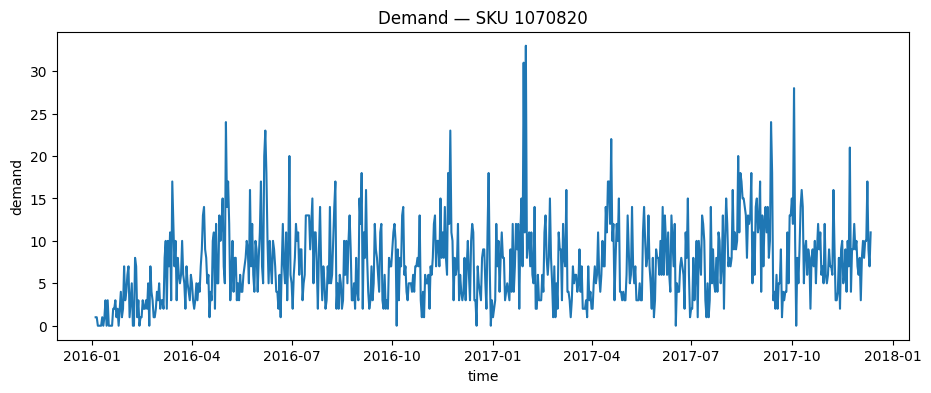

In [28]:
def make_daily_series(df, sku):
    g = df[df[SKU_COL].astype(str) == str(sku)].copy()
    g = g.sort_values(TIME_COL).set_index(TIME_COL)
    full = pd.date_range(g.index.min(), g.index.max(), freq='D')
    g = g.reindex(full)
    g.index.name = TIME_COL
    if PRICE_COL in g.columns:
        g[PRICE_COL] = g[PRICE_COL].ffill()
    g[DEMAND_COL] = g[DEMAND_COL].fillna(0.0)
    g = g.reset_index()
    return g

case_df = make_daily_series(panel, CASE_SKU)
DECISION_DATE = case_df[TIME_COL].max() - pd.Timedelta(days=HORIZON)
case_train = case_df[case_df[TIME_COL] <= DECISION_DATE].copy()
case_test = case_df[case_df[TIME_COL] > DECISION_DATE].copy()

print(f"Decision date: {DECISION_DATE.date()} | Train days: {len(case_train)} | Test days: {len(case_test)}")

plt.figure(figsize=(11, 4))
plt.plot(case_df[TIME_COL], case_df[DEMAND_COL])
plt.title(f'Demand — SKU {CASE_SKU}')
plt.xlabel('time'); plt.ylabel('demand')
plt.show()

## 6) Synthetic future generation

Multiple futures are sampled from the saved SDG model and the best candidate is selected with the notebook scoring rule.

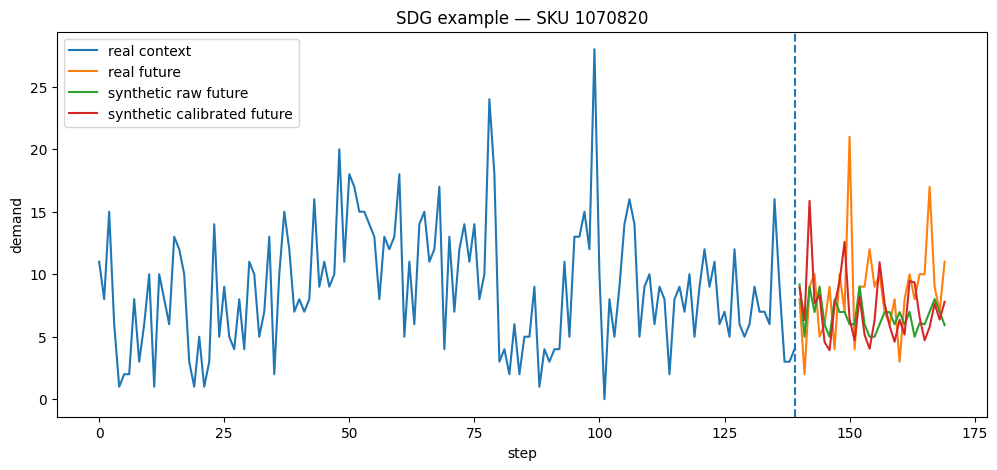

,candidate_index,score
0,5,1.802589
1,3,1.827660
2,8,1.902688
3,9,1.906509
4,0,1.969717
5,2,2.043158
6,6,2.112738
7,4,2.194188
8,7,2.245180
9,1,2.321351


In [29]:
if MODEL_READY:
    context_values = case_train[DEMAND_COL].astype(float).values[-CONTEXT_LENGTH:]
    context_dates = case_train[TIME_COL].iloc[-CONTEXT_LENGTH:].tolist()
    future_dates = case_test[TIME_COL].iloc[:PREDICTION_LENGTH].tolist()
    real_future = case_test[DEMAND_COL].astype(float).values[:PREDICTION_LENGTH]

    gen_out = sdg.generate(
        context_values=context_values,
        horizon=PREDICTION_LENGTH,
        metadata=None,
        num_return_sequences=NUM_RETURN_SEQUENCES,
        do_sample=True,
        temperature=0.9,
        top_p=0.95,
        context_dates=context_dates,
        future_dates=future_dates,
        apply_seasonal_calibration=True,
    )

    best_future = np.asarray(gen_out["best_future"], dtype=float)
    best_raw_future = np.asarray(gen_out["best_raw_future"], dtype=float)

    x_context = np.arange(len(context_values))
    x_future = np.arange(len(context_values), len(context_values) + len(real_future))

    plt.figure(figsize=(12, 5))
    plt.plot(x_context, context_values, label='real context')
    plt.plot(x_future, real_future, label='real future')
    plt.plot(x_future, best_raw_future, label='synthetic raw future')
    plt.plot(x_future, best_future, label='synthetic calibrated future')
    plt.axvline(len(context_values) - 1, linestyle='--')
    plt.title(f'SDG example — SKU {CASE_SKU}')
    plt.xlabel('step'); plt.ylabel('demand')
    plt.legend()
    plt.show()

    candidate_df = pd.DataFrame({
        "candidate_index": list(range(len(gen_out["candidate_scores"]))),
        "score": gen_out["candidate_scores"],
    }).sort_values("score").reset_index(drop=True)
    display(candidate_df.head(10))
else:
    print("Model is not ready. Set train-sdg.ipynb notebook first.")

## 7) Validation metrics

This section defines the validation functions used in the experiments.

In [30]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity


def lag_acf(values, lag):
    x = np.asarray(values, dtype=float).ravel()
    if len(x) <= lag or lag <= 0:
        return 0.0
    x1 = x[:-lag]
    x2 = x[lag:]
    if np.std(x1) < 1e-8 or np.std(x2) < 1e-8:
        return 0.0
    return float(np.corrcoef(x1, x2)[0, 1])

def summarize_windows(windows):
    flat = np.asarray(windows, dtype=float).ravel()
    return {
        'mean': float(np.mean(flat)),
        'std': float(np.std(flat)),
        'median': float(np.median(flat)),
        'zero_share': float(np.mean(flat == 0)),
        'lag1_acf': float(lag_acf(flat, 1)),
        'lag7_acf': float(lag_acf(flat, 7)),
    }

def js_distance_from_hist(real_vals, syn_vals, bins=30):
    lo = min(float(np.min(real_vals)), float(np.min(syn_vals)))
    hi = max(float(np.max(real_vals)), float(np.max(syn_vals)))
    if hi <= lo:
        return 0.0
    h1, edges = np.histogram(real_vals, bins=bins, range=(lo, hi), density=True)
    h2, _ = np.histogram(syn_vals, bins=edges, density=True)
    h1 = h1 + 1e-12
    h2 = h2 + 1e-12
    h1 = h1 / h1.sum()
    h2 = h2 / h2.sum()
    return float(jensenshannon(h1, h2))

def tstr_trts_metrics(real_windows, syn_windows):
    real_windows = np.asarray(real_windows, dtype=float)
    syn_windows = np.asarray(syn_windows, dtype=float)
    if len(real_windows) < 4 or len(syn_windows) < 4:
        return {'tstr': {'mae': np.nan, 'rmse': np.nan}, 'trts': {'mae': np.nan, 'rmse': np.nan}}

    X_real = real_windows[:, :-1]
    y_real = real_windows[:, -1]
    X_syn = syn_windows[:, :-1]
    y_syn = syn_windows[:, -1]

    Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_real, y_real, test_size=0.3, random_state=42)
    Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_syn, y_syn, test_size=0.3, random_state=42)

    rf_tstr = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_tstr.fit(Xs_tr, ys_tr)
    pred_tstr = rf_tstr.predict(Xr_te)

    rf_trts = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_trts.fit(Xr_tr, yr_tr)
    pred_trts = rf_trts.predict(Xs_te)

    return {
        'tstr': {
            'mae': float(mean_absolute_error(yr_te, pred_tstr)),
            'rmse': float(np.sqrt(mean_squared_error(yr_te, pred_tstr))),
        },
        'trts': {
            'mae': float(mean_absolute_error(ys_te, pred_trts)),
            'rmse': float(np.sqrt(mean_squared_error(ys_te, pred_trts))),
        }
    }

def detection_auc(real_windows, syn_windows):
    X = np.vstack([real_windows, syn_windows])
    y = np.array([1] * len(real_windows) + [0] * len(syn_windows))
    if len(np.unique(y)) < 2 or len(X) < 10:
        return np.nan
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(Xtr, ytr)
    proba = clf.predict_proba(Xte)[:, 1]
    return float(roc_auc_score(yte, proba))

def privacy_proxy(real_windows, syn_windows):
    real = np.asarray(real_windows, dtype=float)
    syn = np.asarray(syn_windows, dtype=float)
    def pairwise_min_mean(A, B):
        d = ((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=2) ** 0.5
        return float(np.mean(np.min(d, axis=1)))
    syn_to_real = pairwise_min_mean(syn, real)
    real_to_real = pairwise_min_mean(real, real + 1e-12)
    ratio = syn_to_real / real_to_real if real_to_real > 1e-8 else np.nan
    return {
        'syn_to_real_mean_min_dist': syn_to_real,
        'real_to_real_mean_min_dist': real_to_real,
        'nn_distance_ratio': ratio,
    }

## 8) Multi-SKU evaluation

The saved model is evaluated on the test SKUs using time-based holdouts.

Evaluated test SKUs: 20


,sku,mae,rmse,candidate_score
0,1085604,1.848217,2.210602,1.252617
1,1127831,2.367275,2.965936,1.486215
2,1081177,2.728648,3.106961,1.291583
3,986912,2.601584,3.236537,1.607413
4,962568,3.111455,4.111845,1.375689
5,1070820,2.958568,4.309351,1.612849
6,847270,3.477917,4.315851,1.172088
7,968215,3.549128,4.447556,1.376931
8,1092026,3.432582,4.449173,1.346261
9,834484,3.689779,4.697856,1.079116


{
  "real_summary": {
    "mean": 176.66166666666666,
    "std": 1349.4118819682974,
    "median": 5.0,
    "zero_share": 0.155,
    "lag1_acf": 0.06821088194018826,
    "lag7_acf": 0.03364854124737079
  },
  "synthetic_summary": {
    "mean": 144.5513467483645,
    "std": 1241.1816672628177,
    "median": 5.759085654821183,
    "zero_share": 0.07333333333333333,
    "lag1_acf": 0.018655240462896985,
    "lag7_acf": 0.8573425922254508
  },
  "wasserstein_distance": 66.48576026937738,
  "avg_cosine_similarity": 0.6960247791644778,
  "avg_jensen_shannon_distance": 0.5694697374234141,
  "tstr": {
    "mae": 2208.883537416634,
    "rmse": 5402.444580378783
  },
  "trts": {
    "mae": 361.4548044279268,
    "rmse": 514.3048821435069
  },
  "detection_auc": 0.6666666666666667,
  "privacy_proxy": {
    "syn_to_real_mean_min_dist": 1928.5148714810682,
    "real_to_real_mean_min_dist": 5.553013393633783e-12,
    "nn_distance_ratio": NaN
  }
}


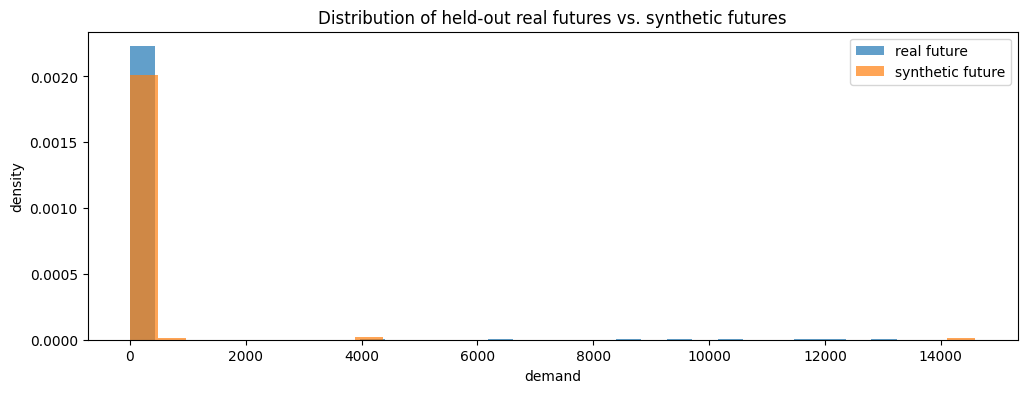

In [31]:
if MODEL_READY:
    eval_skus = list(TEST_SKUs)
    if MAX_EVAL_TEST_SKUS is not None:
        eval_skus = eval_skus[:int(MAX_EVAL_TEST_SKUS)]

    real_windows = []
    syn_windows = []
    rows = []

    for sku in eval_skus:
        sku_df = make_daily_series(panel, sku)
        decision_date = sku_df[TIME_COL].max() - pd.Timedelta(days=HORIZON)
        sku_train = sku_df[sku_df[TIME_COL] <= decision_date].copy()
        sku_test = sku_df[sku_df[TIME_COL] > decision_date].copy()

        if len(sku_train) < CONTEXT_LENGTH or len(sku_test) < PREDICTION_LENGTH:
            continue

        context_values = sku_train[DEMAND_COL].astype(float).values[-CONTEXT_LENGTH:]
        context_dates = sku_train[TIME_COL].iloc[-CONTEXT_LENGTH:].tolist()
        future_dates = sku_test[TIME_COL].iloc[:PREDICTION_LENGTH].tolist()
        real_future = sku_test[DEMAND_COL].astype(float).values[:PREDICTION_LENGTH]

        out = sdg.generate(
            context_values=context_values,
            horizon=PREDICTION_LENGTH,
            metadata=None,
            num_return_sequences=NUM_RETURN_SEQUENCES,
            do_sample=True,
            temperature=0.9,
            top_p=0.95,
            context_dates=context_dates,
            future_dates=future_dates,
            apply_seasonal_calibration=True,
        )
        syn_future = np.asarray(out["best_future"], dtype=float)

        real_windows.append(real_future)
        syn_windows.append(syn_future)

        rows.append({
            "sku": str(sku),
            "mae": float(mean_absolute_error(real_future, syn_future)),
            "rmse": float(np.sqrt(mean_squared_error(real_future, syn_future))),
            "candidate_score": float(out["candidate_scores"][out["best_index"]]),
        })

    eval_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    print("Evaluated test SKUs:", len(eval_df))
    display(eval_df.head(20))

    real_arr = np.asarray(real_windows, dtype=float)
    syn_arr = np.asarray(syn_windows, dtype=float)

    metrics = {
        'real_summary': summarize_windows(real_arr),
        'synthetic_summary': summarize_windows(syn_arr),
        'wasserstein_distance': float(wasserstein_distance(real_arr.ravel(), syn_arr.ravel())),
        'avg_cosine_similarity': float(np.mean([cosine_similarity(r.reshape(1, -1), s.reshape(1, -1))[0, 0] for r, s in zip(real_arr, syn_arr)])),
        'avg_jensen_shannon_distance': float(np.mean([js_distance_from_hist(r, s) for r, s in zip(real_arr, syn_arr)])),
    }
    metrics.update(tstr_trts_metrics(real_arr, syn_arr))
    metrics['detection_auc'] = detection_auc(real_arr, syn_arr)
    metrics['privacy_proxy'] = privacy_proxy(real_arr, syn_arr)

    print(json.dumps(metrics, indent=2))

    plt.figure(figsize=(12, 4))
    plt.hist(real_arr.ravel(), bins=30, alpha=0.7, density=True, label='real future')
    plt.hist(syn_arr.ravel(), bins=30, alpha=0.7, density=True, label='synthetic future')
    plt.title('Distribution of held-out real futures vs. synthetic futures')
    plt.xlabel('demand'); plt.ylabel('density')
    plt.legend()
    plt.show()

    eval_df.to_csv(OUT_DIR / "sdg_eval_per_sku.csv", index=False)
    (OUT_DIR / "sdg_eval_summary.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
else:
    print("Model is not ready. Aggregate evaluation skipped.")

## 9) Benchmark comparison models (GAN, TimeGAN, DGAN, LSTM)

In [32]:
from src.sdg_compare_utils import (
    build_train_windows,
    build_eval_cases,
    evaluate_generator_on_cases,
    comparison_summary_table,
    windows_to_feature_dataframe,
    average_cosine_similarity,
    average_jensen_shannon_distance,
)
from src.gan import GANTimeSeriesGenerator
from src.timegan import TimeGANGenerator
from src.dgan import DGANGenerator
from src.lstm import LSTMForecastGenerator

# Benchmark configuration
RUN_BENCHMARK_COMPARISON = True
BENCHMARK_TRAIN_STRIDE = 7
BENCHMARK_MAX_WINDOWS_PER_TRAIN_SKU = None
BENCHMARK_MAX_EVAL_TEST_SKUS = MAX_EVAL_TEST_SKUS
BENCHMARK_SEED = 42

GAN_EPOCHS = 40
TIMEGAN_EPOCHS = 40
DGAN_EPOCHS = 40
LSTM_EPOCHS = 40
BENCHMARK_BATCH_SIZE = 64
BENCHMARK_HIDDEN_DIM = 64

print("RUN_BENCHMARK_COMPARISON:", RUN_BENCHMARK_COMPARISON)

RUN_BENCHMARK_COMPARISON: True


## 10) Build shared benchmark datasets

In [33]:
if RUN_BENCHMARK_COMPARISON:
    X_train_bench, Y_train_bench, benchmark_train_meta = build_train_windows(
        panel_df=panel,
        skus=TRAIN_SKUs,
        sku_col=SKU_COL,
        time_col=TIME_COL,
        price_col=PRICE_COL,
        demand_col=DEMAND_COL,
        context_length=CONTEXT_LENGTH,
        horizon=PREDICTION_LENGTH,
        stride=BENCHMARK_TRAIN_STRIDE,
        max_windows_per_sku=BENCHMARK_MAX_WINDOWS_PER_TRAIN_SKU,
    )
    eval_skus_bench = list(TEST_SKUs)
    if BENCHMARK_MAX_EVAL_TEST_SKUS is not None:
        eval_skus_bench = eval_skus_bench[:int(BENCHMARK_MAX_EVAL_TEST_SKUS)]
    benchmark_eval_cases = build_eval_cases(
        panel_df=panel,
        skus=eval_skus_bench,
        sku_col=SKU_COL,
        time_col=TIME_COL,
        price_col=PRICE_COL,
        demand_col=DEMAND_COL,
        context_length=CONTEXT_LENGTH,
        horizon=PREDICTION_LENGTH,
    )

    print("Benchmark train windows:", X_train_bench.shape, Y_train_bench.shape)
    print("Benchmark eval cases:", len(benchmark_eval_cases))
    display(benchmark_train_meta.head())
else:
    X_train_bench = np.empty((0, CONTEXT_LENGTH))
    Y_train_bench = np.empty((0, PREDICTION_LENGTH))
    benchmark_eval_cases = []

Benchmark train windows: (6174, 140) (6174, 30)
Benchmark eval cases: 20


,sku,context_start,context_end,future_end
0,820165,0,140,170
1,820165,7,147,177
2,820165,14,154,184
3,820165,21,161,191
4,820165,28,168,198


## 11) Train comparison models

In [34]:
benchmark_models = {}
benchmark_results = {}

if RUN_BENCHMARK_COMPARISON:
    benchmark_models["gan"] = GANTimeSeriesGenerator(
        context_length=CONTEXT_LENGTH,
        horizon=PREDICTION_LENGTH,
        hidden_dim=BENCHMARK_HIDDEN_DIM,
        batch_size=BENCHMARK_BATCH_SIZE,
        epochs=GAN_EPOCHS,
        seed=BENCHMARK_SEED,
    ).fit(X_train_bench, Y_train_bench, verbose=True)

    benchmark_models["timegan"] = TimeGANGenerator(
        context_length=CONTEXT_LENGTH,
        horizon=PREDICTION_LENGTH,
        hidden_dim=BENCHMARK_HIDDEN_DIM,
        batch_size=BENCHMARK_BATCH_SIZE,
        epochs=TIMEGAN_EPOCHS,
        seed=BENCHMARK_SEED,
    ).fit(X_train_bench, Y_train_bench, verbose=True)

    benchmark_models["dgan"] = DGANGenerator(
        context_length=CONTEXT_LENGTH,
        horizon=PREDICTION_LENGTH,
        hidden_dim=max(96, BENCHMARK_HIDDEN_DIM),
        batch_size=BENCHMARK_BATCH_SIZE,
        epochs=DGAN_EPOCHS,
        seed=BENCHMARK_SEED,
    ).fit(X_train_bench, Y_train_bench, verbose=True)

    benchmark_models["lstm"] = LSTMForecastGenerator(
        context_length=CONTEXT_LENGTH,
        horizon=PREDICTION_LENGTH,
        hidden_dim=BENCHMARK_HIDDEN_DIM,
        batch_size=BENCHMARK_BATCH_SIZE,
        epochs=LSTM_EPOCHS,
        seed=BENCHMARK_SEED,
    ).fit(X_train_bench, Y_train_bench, verbose=True)

    print("Trained benchmark models:", list(benchmark_models))
else:
    print("Benchmark comparison disabled.")

[GAN] epoch=1/40 loss_d=1.2861 loss_g=0.7782
[GAN] epoch=10/40 loss_d=1.4650 loss_g=0.6625
[GAN] epoch=20/40 loss_d=1.4153 loss_g=0.6898
[GAN] epoch=30/40 loss_d=1.4124 loss_g=0.6210
[GAN] epoch=40/40 loss_d=1.3826 loss_g=0.7080
[TimeGAN] epoch=1/40 loss=0.5781
[TimeGAN] epoch=10/40 loss=0.2414
[TimeGAN] epoch=20/40 loss=0.0122
[TimeGAN] epoch=30/40 loss=0.0000
[TimeGAN] epoch=40/40 loss=0.1107
[DGAN] epoch=1/40 loss=0.1473
[DGAN] epoch=10/40 loss=0.0103
[DGAN] epoch=20/40 loss=0.0130
[DGAN] epoch=30/40 loss=0.0253
[DGAN] epoch=40/40 loss=0.0071
[LSTM] epoch=1/40 loss=0.1488
[LSTM] epoch=10/40 loss=0.2244
[LSTM] epoch=20/40 loss=0.0125
[LSTM] epoch=30/40 loss=0.0000
[LSTM] epoch=40/40 loss=0.1367
Trained benchmark models: ['gan', 'timegan', 'dgan', 'lstm']


## 12) Evaluate benchmark models on the same held-out SKU futures

In [35]:
if RUN_BENCHMARK_COMPARISON:
    # Proposed SDG result from existing cells
    if MODEL_READY and 'eval_df' in globals() and 'metrics' in globals():
        benchmark_results["proposed_sdg"] = {
            "per_sku": eval_df.copy(),
            "real_arr": real_arr.copy(),
            "syn_arr": syn_arr.copy(),
            "metrics": dict(metrics),
        }
    else:
        print("Proposed SDG evaluation is not available; benchmark table will contain only baseline models.")

    for model_name, model_obj in benchmark_models.items():
        per_sku_df, real_model_arr, syn_model_arr, model_metrics = evaluate_generator_on_cases(
            model=model_obj,
            eval_cases=benchmark_eval_cases,
            model_name=model_name,
        )
        benchmark_results[model_name] = {
            "per_sku": per_sku_df,
            "real_arr": real_model_arr,
            "syn_arr": syn_model_arr,
            "metrics": model_metrics,
        }
        print(f"{model_name}: evaluated {len(per_sku_df)} SKUs")
        display(per_sku_df.head())

    benchmark_summary = comparison_summary_table(benchmark_results)
    display(benchmark_summary)
    benchmark_summary.to_csv(OUT_DIR / "sdg_compare_summary.csv", index=False)

    metrics_json = {}
    for name, payload in benchmark_results.items():
        serializable = dict(payload["metrics"])
        serializable.pop("case_predictions", None)
        metrics_json[name] = serializable
    (OUT_DIR / "sdg_compare_metrics.json").write_text(json.dumps(metrics_json, indent=2), encoding="utf-8")
else:
    print("Benchmark comparison disabled.")

gan: evaluated 20 SKUs


,model,sku,mae,rmse
0,gan,5569471,597.120321,934.449817
1,gan,1085604,597.972274,936.848637
2,gan,953476,596.931836,934.625648
3,gan,1070820,596.442090,933.565704
4,gan,1081177,597.458993,936.387679


timegan: evaluated 20 SKUs


,model,sku,mae,rmse
0,timegan,5569471,6.8,10.437113
1,timegan,1085604,3.2,3.714835
2,timegan,953476,5.2,7.487768
3,timegan,1070820,8.6,9.355925
4,timegan,1081177,4.4,5.163978


dgan: evaluated 20 SKUs


,model,sku,mae,rmse
0,dgan,5569471,52.827214,94.819483
1,dgan,1085604,49.364648,94.724874
2,dgan,953476,51.078939,95.333351
3,dgan,1070820,52.271501,94.066698
4,dgan,1081177,50.284701,94.908859


lstm: evaluated 20 SKUs


,model,sku,mae,rmse
0,lstm,5569471,32.955143,58.207790
1,lstm,1085604,32.009277,58.799668
2,lstm,953476,33.187223,58.511080
3,lstm,1070820,33.930225,56.728574
4,lstm,1081177,32.777881,58.715759


,model,mean,std,zero_share,wasserstein_distance,avg_cosine_similarity,avg_jensen_shannon_distance,pearson_corr,tstr_mae,trts_mae,detection_auc,nn_distance_ratio,avg_rmse
0,timegan,75.346430,264.768812,0.893333,197.914184,0.086601,0.738437,0.257268,2188.759987,3163.167051,0.833333,0.194463,406.317495
1,lstm,54.786236,106.660402,0.578333,200.539543,0.370146,0.497227,0.217095,2195.164678,2013.716549,1.000000,0.190767,456.570335
2,dgan,286.241052,975.282813,0.601667,254.287050,0.368198,0.459083,0.422258,2144.141460,2395.847220,1.000000,0.968670,486.113234
3,proposed_sdg,144.551347,1241.181667,0.073333,66.485760,0.696025,0.569470,NaN,2208.883537,361.454804,0.666667,NaN,526.900901
4,gan,619.242782,741.567832,0.396667,702.769283,0.534226,0.522457,0.036811,2264.799559,1246.865000,1.000000,2.302448,1235.360409


## 13) Compare feature correlations, value distributions, and one-step differences

Correlation in real held-out futures:


,step_000,step_001,step_002,step_003,step_004,step_005,step_006,step_007,step_008,step_009,...,step_020,step_021,step_022,step_023,step_024,step_025,step_026,step_027,step_028,step_029
step_000,1.000000,0.855984,-0.259152,-0.177919,0.920315,0.928247,0.863912,-0.178505,0.936489,0.913591,...,-0.179671,0.947225,-0.173198,0.894400,-0.180614,0.266200,0.247108,0.598066,0.554064,-0.247956
step_001,0.855984,1.000000,-0.260481,-0.178802,0.865949,0.869779,0.780953,-0.179537,0.882158,0.871367,...,-0.180662,0.895868,-0.174583,0.873039,-0.181548,0.224388,0.200497,0.492680,0.487407,-0.248973
step_002,-0.259152,-0.260481,1.000000,0.664127,-0.193446,-0.194706,-0.265111,0.710564,-0.181370,-0.258448,...,0.664512,-0.207973,0.663157,-0.274601,0.664500,-0.329976,-0.290639,-0.370199,-0.342257,0.930794
step_003,-0.177919,-0.178802,0.664127,1.000000,-0.132536,-0.133441,-0.181489,-0.054143,-0.124145,-0.177151,...,0.999993,-0.142492,0.999977,-0.188742,0.999991,-0.226550,-0.199127,-0.253745,-0.234382,0.891430
step_004,0.920315,0.865949,-0.193446,-0.132536,1.000000,0.952381,0.878498,-0.133343,0.978275,0.930637,...,-0.134706,0.964842,-0.127875,0.872801,-0.135658,0.262992,0.276196,0.573365,0.577723,-0.186255
step_005,0.928247,0.869779,-0.194706,-0.133441,0.952381,1.000000,0.864574,-0.134323,0.979949,0.915540,...,-0.135435,0.957829,-0.128552,0.851197,-0.136320,0.307781,0.281197,0.657317,0.571440,-0.187194
step_006,0.863912,0.780953,-0.265111,-0.181489,0.878498,0.864574,1.000000,-0.182685,0.881226,0.899219,...,-0.183948,0.918708,-0.177777,0.751794,-0.184841,0.168419,0.220242,0.578213,0.500098,-0.253697
step_007,-0.178505,-0.179537,0.710564,-0.054143,-0.133343,-0.134323,-0.182685,1.000000,-0.125081,-0.178042,...,-0.053628,-0.143349,-0.055418,-0.189121,-0.053642,-0.227362,-0.200246,-0.255161,-0.235687,0.404201
step_008,0.936489,0.882158,-0.181370,-0.124145,0.978275,0.979949,0.881226,-0.125081,1.000000,0.934520,...,-0.126300,0.979609,-0.119217,0.877187,-0.127264,0.293813,0.310696,0.634866,0.590722,-0.174789
step_009,0.913591,0.871367,-0.258448,-0.177151,0.930637,0.915540,0.899219,-0.178042,0.934520,1.000000,...,-0.179434,0.972782,-0.171820,0.895362,-0.180295,0.209943,0.222556,0.535815,0.573343,-0.247279


Correlation in synthetic futures for proposed_sdg:


,step_000,step_001,step_002,step_003,step_004,step_005,step_006,step_007,step_008,step_009,...,step_020,step_021,step_022,step_023,step_024,step_025,step_026,step_027,step_028,step_029
step_000,1.000000,-0.101545,0.945007,0.962418,0.145801,0.132152,0.018007,0.980887,-0.103448,0.944627,...,0.062046,0.989498,-0.103702,0.944829,0.960615,0.071151,0.032007,-0.085392,0.955514,-0.106185
step_001,-0.101545,1.000000,-0.056855,-0.069909,-0.157753,-0.168535,-0.250358,-0.086082,0.999952,-0.056797,...,-0.223277,-0.088503,0.999946,-0.056803,-0.069886,-0.204879,-0.244210,-0.213572,-0.090984,0.999828
step_002,0.945007,-0.056855,1.000000,0.997863,-0.173563,-0.184152,-0.263760,0.988689,-0.055844,0.999997,...,-0.237827,0.976301,-0.056025,0.999998,0.998106,-0.218626,-0.258408,-0.219772,0.988567,-0.056193
step_003,0.962418,-0.069909,0.997863,1.000000,-0.112887,-0.124436,-0.215825,0.995385,-0.069376,0.997810,...,-0.184731,0.986952,-0.069595,0.997837,0.999385,-0.167809,-0.204830,-0.185767,0.992133,-0.070109
step_004,0.145801,-0.157753,-0.173563,-0.112887,1.000000,0.950245,0.801179,-0.028043,-0.165981,-0.174569,...,0.888399,0.029835,-0.166298,-0.174009,-0.120356,0.832870,0.854233,0.408445,-0.101506,-0.172871
step_005,0.132152,-0.168535,-0.184152,-0.124436,0.950245,1.000000,0.848621,-0.047305,-0.177063,-0.185437,...,0.840309,0.003042,-0.177643,-0.184932,-0.135775,0.820361,0.882538,0.431720,-0.117516,-0.183769
step_006,0.018007,-0.250358,-0.263760,-0.215825,0.801179,0.848621,1.000000,-0.140797,-0.257925,-0.265215,...,0.864506,-0.101976,-0.257673,-0.264656,-0.221888,0.870641,0.872992,0.469412,-0.200284,-0.262792
step_007,0.980887,-0.086082,0.988689,0.995385,-0.028043,-0.047305,-0.140797,1.000000,-0.086282,0.988549,...,-0.102867,0.995893,-0.086533,0.988624,0.994601,-0.092296,-0.131294,-0.165806,0.987316,-0.087763
step_008,-0.103448,0.999952,-0.055844,-0.069376,-0.165981,-0.177063,-0.257925,-0.086282,1.000000,-0.055773,...,-0.230806,-0.089180,0.999990,-0.055785,-0.069313,-0.212498,-0.251965,-0.217270,-0.090569,0.999926
step_009,0.944627,-0.056797,0.999997,0.997810,-0.174569,-0.185437,-0.265215,0.988549,-0.055773,1.000000,...,-0.238858,0.976146,-0.055953,0.999999,0.998052,-0.219679,-0.259367,-0.220474,0.988475,-0.056117


Correlation in synthetic futures for gan:


...

,step_000,step_001,step_002,step_003,step_004,step_005,step_006,step_007,step_008,step_009,...,step_020,step_021,step_022,step_023,step_024,step_025,step_026,step_027,step_028,step_029
step_000,1.000000,0.999838,0.999992,0.999765,0.999252,0.998484,0.997455,0.996163,0.994624,0.992885,...,0.973006,0.971347,0.969651,0.967900,0.966076,0.964165,0.962148,0.960013,0.957743,0.955323
step_001,0.999838,1.000000,0.999790,0.999389,0.998708,0.997778,0.996590,0.995137,0.993441,0.991548,...,0.970569,0.968843,0.967080,0.965262,0.963370,0.961389,0.959302,0.957093,0.954748,0.952250
step_002,0.999992,0.999790,1.000000,0.999844,0.999399,0.998696,0.997733,0.996506,0.995032,0.993354,...,0.973924,0.972292,0.970624,0.968901,0.967104,0.965221,0.963234,0.961128,0.958889,0.956501
step_003,0.999765,0.999389,0.999844,1.000000,0.999855,0.999442,0.998766,0.997826,0.996635,0.995232,...,0.977779,0.976270,0.974723,0.973121,0.971447,0.969689,0.967830,0.965856,0.963753,0.961505
step_004,0.999252,0.998708,0.999399,0.999855,1.000000,0.999866,0.999466,0.998802,0.997885,0.996747,...,0.981202,0.979811,0.978381,0.976895,0.975341,0.973703,0.971967,0.970121,0.968149,0.966038
step_005,0.998484,0.997778,0.998696,0.999442,0.999866,1.000000,0.999868,0.999470,0.998817,0.997934,...,0.984235,0.982957,0.981640,0.980269,0.978828,0.977308,0.975692,0.973969,0.972125,0.970145
step_006,0.997455,0.996590,0.997733,0.998766,0.999466,0.999868,1.000000,0.999868,0.999476,0.998848,...,0.986983,0.985819,0.984615,0.983356,0.982030,0.980626,0.979129,0.977529,0.975812,0.973964
step_007,0.996163,0.995137,0.996506,0.997826,0.998802,0.999470,0.999868,1.000000,0.999870,0.999497,...,0.989470,0.988420,0.987328,0.986183,0.984972,0.983684,0.982308,0.980831,0.979241,0.977525
step_008,0.994624,0.993441,0.995032,0.996635,0.997885,0.998817,0.999476,0.999870,1.000000,0.999878,...,0.991672,0.990735,0.989756,0.988723,0.987625,0.986454,0.985196,0.983841,0.982378,0.980793
step_009,0.992885,0.991548,0.993354,0.995232,0.996747,0.997934,0.998848,0.999497,0.999878,1.000000,...,0.993564,0.992737,0.991866,0.990942,0.989956,0.988897,0.987755,0.986519,0.985179,0.983721


Correlation in synthetic futures for dgan:


,step_000,step_001,step_002,step_003,step_004,step_005,step_006,step_007,step_008,step_009,...,step_020,step_021,step_022,step_023,step_024,step_025,step_026,step_027,step_028,step_029
step_000,1.000000,0.042668,0.042668,0.603503,0.999816,0.377077,0.683609,0.714599,0.819177,0.995398,...,0.995360,0.858506,0.643869,0.999753,0.102431,0.042668,NaN,0.855528,0.042668,0.432675
step_001,0.042668,1.000000,1.000000,0.822379,0.027256,0.941417,0.758329,0.729344,0.607900,-0.052688,...,-0.053419,0.548878,0.791880,0.061738,0.998153,1.000000,NaN,0.553701,1.000000,0.919185
step_002,0.042668,1.000000,1.000000,0.822379,0.027256,0.941417,0.758329,0.729344,0.607900,-0.052688,...,-0.053419,0.548878,0.791880,0.061738,0.998153,1.000000,NaN,0.553701,1.000000,0.919185
step_003,0.603503,0.822379,0.822379,1.000000,0.591122,0.966063,0.994475,0.989021,0.951653,0.524803,...,0.524187,0.926946,0.998650,0.618605,0.854927,0.822379,NaN,0.929101,0.822379,0.979980
step_004,0.999816,0.027256,0.027256,0.591122,1.000000,0.362777,0.672192,0.703772,0.810288,0.996803,...,0.996668,0.850552,0.632034,0.999404,0.086971,0.027256,NaN,0.847496,0.027256,0.418717
step_005,0.377077,0.941417,0.941417,0.966063,0.362777,1.000000,0.933702,0.917340,0.840062,0.287172,...,0.286439,0.798625,0.951435,0.394720,0.959837,0.941417,NaN,0.802090,0.941417,0.998144
step_006,0.683609,0.758329,0.758329,0.994475,0.672192,0.933702,1.000000,0.998986,0.978498,0.610913,...,0.610370,0.961042,0.998523,0.697340,0.795991,0.758329,NaN,0.962619,0.758329,0.953735
step_007,0.714599,0.729344,0.729344,0.989021,0.703772,0.917340,0.998986,1.000000,0.986590,0.644769,...,0.644157,0.972201,0.995346,0.727870,0.768901,0.729344,NaN,0.973537,0.729344,0.939826
step_008,0.819177,0.607900,0.607900,0.951653,0.810288,0.840062,0.978498,0.986590,1.000000,0.760882,...,0.760346,0.997381,0.966269,0.830030,0.654249,0.607900,NaN,0.997781,0.607900,0.871463
step_009,0.995398,-0.052688,-0.052688,0.524803,0.996803,0.287172,0.610913,0.644769,0.760882,1.000000,...,0.999935,0.805822,0.568106,0.993453,0.007123,-0.052688,NaN,0.802383,-0.052688,0.344836


Correlation in synthetic futures for lstm:


,step_000,step_001,step_002,step_003,step_004,step_005,step_006,step_007,step_008,step_009,...,step_020,step_021,step_022,step_023,step_024,step_025,step_026,step_027,step_028,step_029
step_000,1.000000,0.978591,0.993524,0.984473,0.995703,0.996590,0.981676,0.970013,0.995703,0.986347,...,0.987388,0.996225,0.995703,0.990865,0.979934,0.979590,0.986241,0.978851,0.997588,0.975927
step_001,0.978591,1.000000,0.995633,0.999516,0.955331,0.992232,0.999879,0.999264,0.955331,0.999116,...,0.998826,0.992759,0.955331,0.997401,0.999978,0.999986,0.999145,0.999990,0.961949,0.999919
step_002,0.993524,0.995633,1.000000,0.998042,0.978734,0.999511,0.996965,0.991329,0.978734,0.998671,...,0.998982,0.999637,0.978734,0.999771,0.996228,0.996074,0.998637,0.995756,0.983242,0.994385
step_003,0.984473,0.999516,0.998042,1.000000,0.963988,0.995600,0.999875,0.997588,0.963988,0.999939,...,0.999847,0.995994,0.963988,0.999152,0.999696,0.999647,0.999946,0.999563,0.969915,0.999054
step_004,0.995703,0.955331,0.978734,0.963988,1.000000,0.984667,0.959816,0.943353,1.000000,0.966859,...,0.968485,0.983906,1.000000,0.974119,0.957271,0.956776,0.966695,0.955702,0.999729,0.951539
step_005,0.996590,0.992232,0.999511,0.995600,0.984667,1.000000,0.994048,0.986747,0.984667,0.996572,...,0.997085,0.999991,0.984667,0.998614,0.993034,0.992827,0.996518,0.992393,0.988460,0.990593
step_006,0.981676,0.999879,0.996965,0.999875,0.959816,0.994048,1.000000,0.998549,0.959816,0.999647,...,0.999457,0.994508,0.959816,0.998400,0.999960,0.999942,0.999665,0.999888,0.966085,0.999602
step_007,0.970013,0.999264,0.991329,0.997588,0.943353,0.986747,0.998549,1.000000,0.943353,0.996769,...,0.996234,0.987436,0.943353,0.993908,0.998992,0.999070,0.996824,0.999188,0.950816,0.999657
step_008,0.995703,0.955331,0.978734,0.963988,1.000000,0.984667,0.959816,0.943353,1.000000,0.966859,...,0.968485,0.983906,1.000000,0.974119,0.957271,0.956776,0.966695,0.955702,0.999729,0.951539
step_009,0.986347,0.999116,0.998671,0.999939,0.966859,0.996572,0.999647,0.996769,0.966859,1.000000,...,0.999979,0.996919,0.966859,0.999545,0.999369,0.999301,0.999999,0.999176,0.972538,0.998515


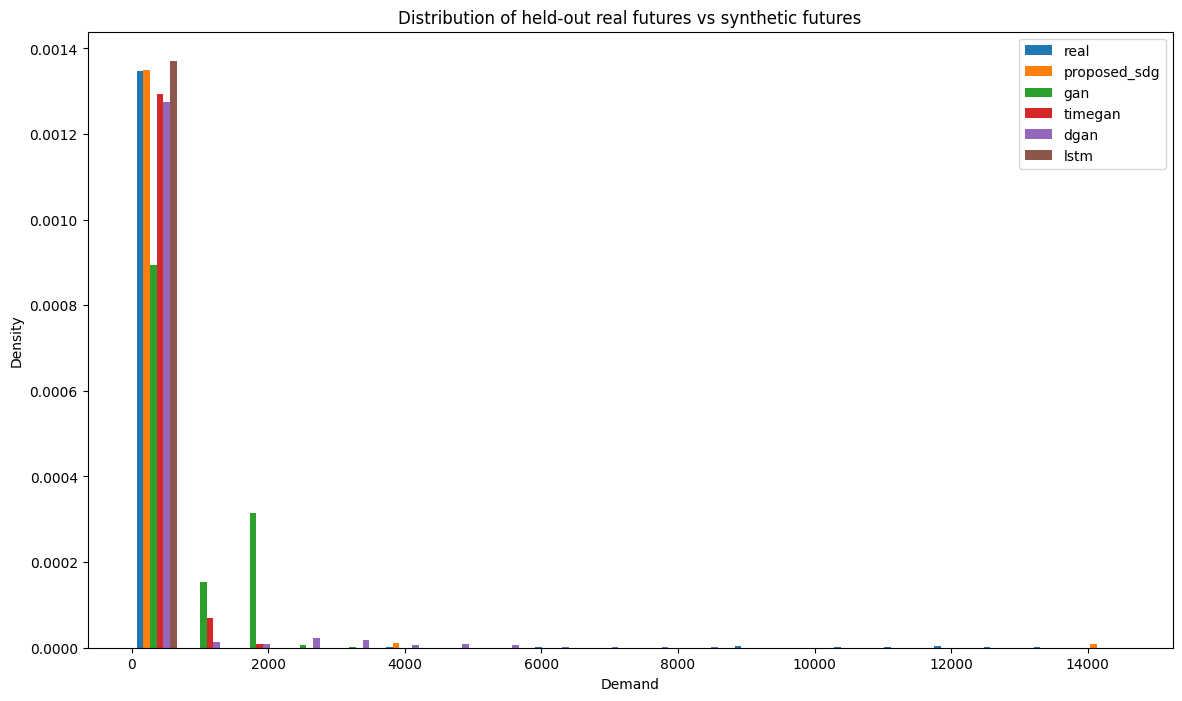

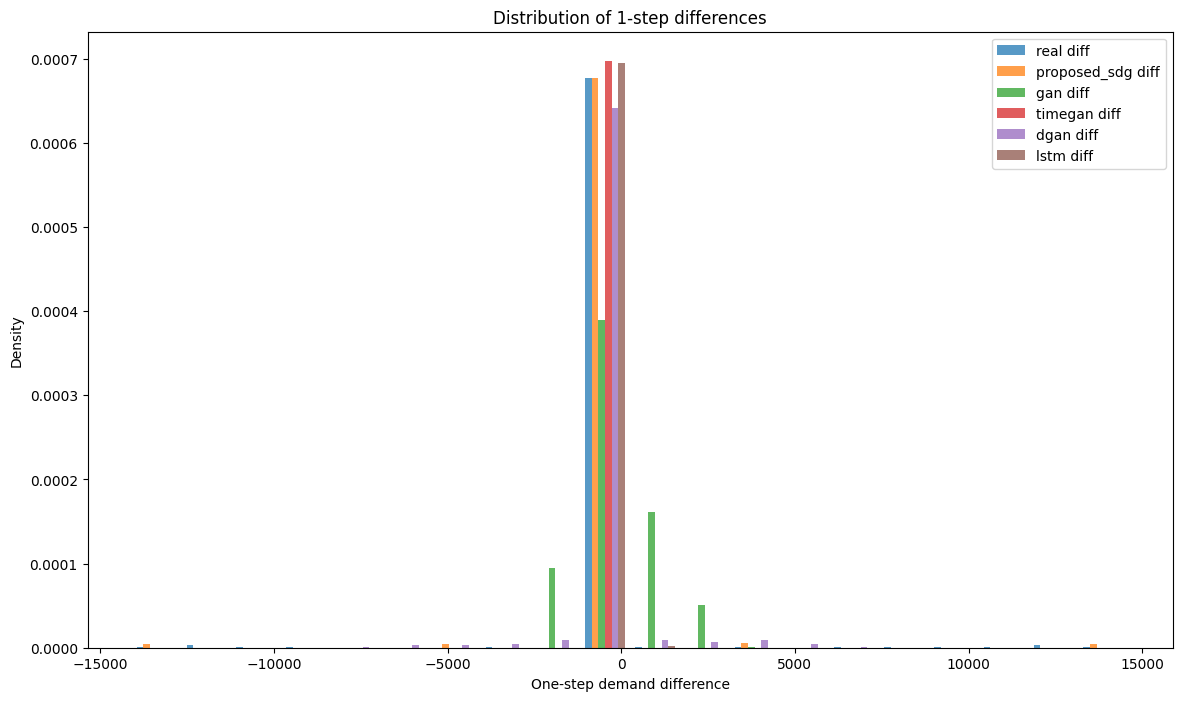

In [36]:
if RUN_BENCHMARK_COMPARISON and benchmark_results:
    real_reference = None
    for payload in benchmark_results.values():
        if payload["real_arr"].size:
            real_reference = payload["real_arr"]
            break

    if real_reference is not None:
        real_df_features = windows_to_feature_dataframe(real_reference, prefix="step")
        print("Correlation in real held-out futures:")
        display(real_df_features.corr())

        for name, payload in benchmark_results.items():
            syn_df_features = windows_to_feature_dataframe(payload["syn_arr"], prefix="step")
            print(f"Correlation in synthetic futures for {name}:")
            display(syn_df_features.corr())

        plt.figure(figsize=(14, 8))
        hist_values = [real_reference.ravel()]
        hist_labels = ["real"]
        for name, payload in benchmark_results.items():
            hist_values.append(payload["syn_arr"].ravel())
            hist_labels.append(name)
        plt.hist(hist_values, label=hist_labels, bins=20, density=True)
        plt.legend()
        plt.xlabel("Demand")
        plt.ylabel("Density")
        plt.title("Distribution of held-out real futures vs synthetic futures")
        plt.show()

        plt.figure(figsize=(14, 8))
        diff_values = [np.diff(real_reference, axis=1).ravel()]
        diff_labels = ["real diff"]
        for name, payload in benchmark_results.items():
            diff_values.append(np.diff(payload["syn_arr"], axis=1).ravel())
            diff_labels.append(f"{name} diff")
        plt.hist(diff_values, label=diff_labels, bins=20, density=True, alpha=0.75)
        plt.legend()
        plt.xlabel("One-step demand difference")
        plt.ylabel("Density")
        plt.title("Distribution of 1-step differences")
        plt.show()
    else:
        print("No benchmark windows available.")

## 14) Similarity statistics and case-SKU comparison plot

,model,avg_cosine_similarity_windowed,avg_jensen_shannon_distance_windowed,pearson_corr_flattened
0,proposed_sdg,0.776589,0.264773,0.193294
1,gan,0.545197,0.515994,0.036811
4,lstm,0.383497,0.652203,0.217095
3,dgan,0.356991,0.686269,0.422258
2,timegan,0.032593,0.959113,0.257268


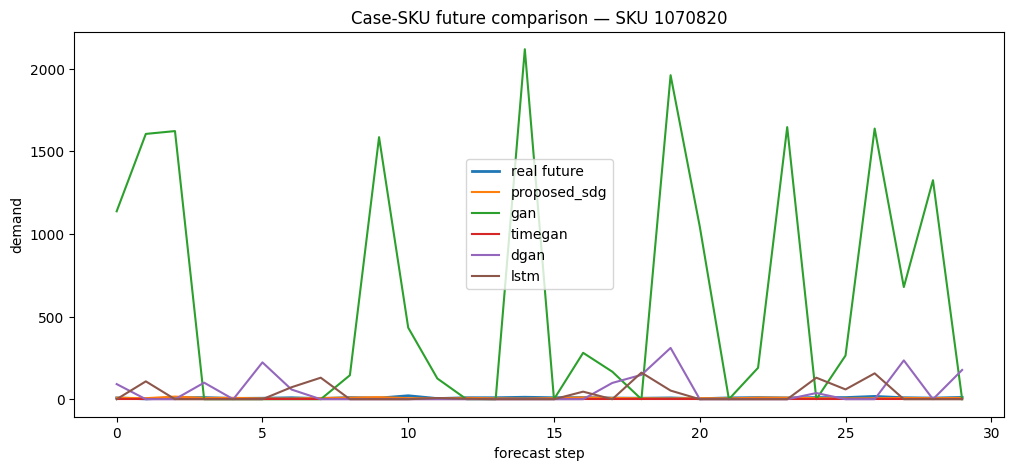

In [37]:
if RUN_BENCHMARK_COMPARISON and benchmark_results:
    real_reference = None
    for payload in benchmark_results.values():
        if payload["real_arr"].size:
            real_reference = payload["real_arr"]
            break

    if real_reference is not None:
        similarity_rows = []
        for name, payload in benchmark_results.items():
            sim_cos = float(np.mean([
                average_cosine_similarity(r, s, window_size=3, step_size=1)
                for r, s in zip(real_reference, payload["syn_arr"])
            ]))
            sim_js = float(np.mean([
                average_jensen_shannon_distance(r, s, window_size=3, step_size=1)
                for r, s in zip(real_reference, payload["syn_arr"])
            ]))
            pearson_corr = float(np.corrcoef(real_reference.ravel(), payload["syn_arr"].ravel())[0, 1])
            similarity_rows.append({
                "model": name,
                "avg_cosine_similarity_windowed": sim_cos,
                "avg_jensen_shannon_distance_windowed": sim_js,
                "pearson_corr_flattened": pearson_corr,
            })

        similarity_df = pd.DataFrame(similarity_rows).sort_values("avg_cosine_similarity_windowed", ascending=False)
        display(similarity_df)
        similarity_df.to_csv(OUT_DIR / "sdg_compare_similarity.csv", index=False)

        if MODEL_READY:
            case_context_values = case_train[DEMAND_COL].astype(float).values[-CONTEXT_LENGTH:]
            case_real_future = case_test[DEMAND_COL].astype(float).values[:PREDICTION_LENGTH]
            case_context_dates = case_train[TIME_COL].iloc[-CONTEXT_LENGTH:].tolist()
            case_future_dates = case_test[TIME_COL].iloc[:PREDICTION_LENGTH].tolist()

            case_predictions = {
                "proposed_sdg": np.asarray(best_future, dtype=float) if 'best_future' in globals() else None
            }
            for name, model_obj in benchmark_models.items():
                case_predictions[name] = np.asarray(
                    model_obj.generate(case_context_values, horizon=PREDICTION_LENGTH),
                    dtype=float,
                )

            plt.figure(figsize=(12, 5))
            plt.plot(case_real_future, label="real future", linewidth=2)
            for name, pred in case_predictions.items():
                if pred is not None:
                    plt.plot(pred, label=name)
            plt.title(f"Case-SKU future comparison — SKU {CASE_SKU}")
            plt.xlabel("forecast step")
            plt.ylabel("demand")
            plt.legend()
            plt.show()
    else:
        print("No benchmark windows available.")

## 15) Evaluation by fidelity, utility, and privacy

The thesis frames the evaluation around three dimensions: **fidelity**, **utility**, and **privacy**.  
The cells below extend the existing DIF-PI SDG validation flow with experiments:
- a **context-window sweep**,
- a **post hoc RNN discriminative score**,
- a **post hoc RNN predictive score**,
- an **XGBoost forecasting score**,
- a **privacy-against-inference** block with four attack models,
- and **cross-product correlation tables** for real and synthetic futures.

All compared baselines are displayed using their direct model names: **GAN**, **TimeGAN**, **DGAN**, and **LSTM**.

In [38]:
# Paper-aligned helpers
import warnings
from copy import deepcopy
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import RadiusNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    HAS_XGBOOST = True
except Exception:
    from sklearn.ensemble import GradientBoostingRegressor
    HAS_XGBOOST = False

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False

MODEL_DISPLAY_NAMES = {
    "proposed_sdg": "Proposed SDG",
    "gan": "GAN",
    "timegan": "TimeGAN",
    "dgan": "DGAN",
    "lstm": "LSTM",
}

def display_name(name):
    return MODEL_DISPLAY_NAMES.get(str(name), str(name))

def get_real_reference(benchmark_results):
    for payload in benchmark_results.values():
        arr = np.asarray(payload.get("real_arr", np.empty((0, 0))), dtype=float)
        if arr.size:
            return arr
    return np.empty((0, 0))

def final_step_dataset(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        return np.empty((0, 0)), np.empty((0,))
    return arr[:, :-1], arr[:, -1]

def privacy_attack_dataset(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 4:
        return np.empty((0, 0)), np.empty((0, 0))
    split = arr.shape[1] // 2
    X = arr[:, :split]
    Y = arr[:, split:]
    return X, Y

def selected_eval_skus(eval_df, max_products=6):
    if 'sku' in eval_df.columns and len(eval_df):
        return list(eval_df['sku'].astype(str).head(max_products))
    return []

def build_case_map(panel_df, skus, context_length, horizon):
    out = {}
    for sku in skus:
        sku_df = make_daily_series(panel_df, sku)
        decision_date = sku_df[TIME_COL].max() - pd.Timedelta(days=horizon)
        sku_train = sku_df[sku_df[TIME_COL] <= decision_date].copy()
        sku_test = sku_df[sku_df[TIME_COL] > decision_date].copy()
        if len(sku_train) < context_length or len(sku_test) < horizon:
            continue
        out[str(sku)] = {
            "train": sku_train,
            "test": sku_test,
            "context_values": sku_train[DEMAND_COL].astype(float).values[-context_length:],
            "context_dates": sku_train[TIME_COL].iloc[-context_length:].tolist(),
            "future_dates": sku_test[TIME_COL].iloc[:horizon].tolist(),
            "real_future": sku_test[DEMAND_COL].astype(float).values[:horizon],
        }
    return out

def model_synthetic_case_predictions(sku_case_map, benchmark_models, proposed_available=True):
    preds = {}
    if proposed_available and MODEL_READY and 'best_future' in globals():
        # case_sku handled separately, not used in generic map
        pass
    for name, model_obj in benchmark_models.items():
        preds[name] = {}
        for sku, payload in sku_case_map.items():
            preds[name][sku] = np.asarray(
                model_obj.generate(payload["context_values"], horizon=PREDICTION_LENGTH),
                dtype=float,
            )
    return preds

if HAS_TORCH:
    class _RNNBinaryClassifier(nn.Module):
        def __init__(self, hidden_dim=32):
            super().__init__()
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
            self.head = nn.Linear(hidden_dim, 1)

        def forward(self, x):
            out, _ = self.rnn(x)
            return self.head(out[:, -1, :]).squeeze(-1)

    class _RNNRegressor(nn.Module):
        def __init__(self, hidden_dim=32):
            super().__init__()
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
            self.head = nn.Linear(hidden_dim, 1)

        def forward(self, x):
            out, _ = self.rnn(x)
            return self.head(out[:, -1, :]).squeeze(-1)

def posthoc_rnn_discriminative_score(real_arr, syn_arr, epochs=12, hidden_dim=32, batch_size=32, seed=42):
    real_arr = np.asarray(real_arr, dtype=float)
    syn_arr = np.asarray(syn_arr, dtype=float)
    if not HAS_TORCH or real_arr.size == 0 or syn_arr.size == 0:
        return {"accuracy": np.nan, "score": np.nan}
    X = np.concatenate([real_arr, syn_arr], axis=0)
    y = np.concatenate([np.ones(len(real_arr)), np.zeros(len(syn_arr))], axis=0)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=seed, stratify=y
    )

    torch.manual_seed(seed)
    model = _RNNBinaryClassifier(hidden_dim=hidden_dim)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()

    ds = TensorDataset(
        torch.tensor(X_train[:, :, None], dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
    )
    dl = DataLoader(ds, batch_size=min(batch_size, len(ds)), shuffle=True)

    model.train()
    for _ in range(int(epochs)):
        for xb, yb in dl:
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.inference_mode():
        logits = model(torch.tensor(X_test[:, :, None], dtype=torch.float32))
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

    acc = float(accuracy_score(y_test, preds))
    score = float(abs(acc - 0.5))
    return {"accuracy": acc, "score": score}

def posthoc_rnn_predictive_score(real_arr, syn_arr, epochs=12, hidden_dim=32, batch_size=32, seed=42):
    real_arr = np.asarray(real_arr, dtype=float)
    syn_arr = np.asarray(syn_arr, dtype=float)
    X_syn, y_syn = final_step_dataset(syn_arr)
    X_real, y_real = final_step_dataset(real_arr)
    if not HAS_TORCH or X_syn.size == 0 or X_real.size == 0:
        return {"mae": np.nan, "rmse": np.nan}

    torch.manual_seed(seed)
    model = _RNNRegressor(hidden_dim=hidden_dim)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    ds = TensorDataset(
        torch.tensor(X_syn[:, :, None], dtype=torch.float32),
        torch.tensor(y_syn, dtype=torch.float32),
    )
    dl = DataLoader(ds, batch_size=min(batch_size, len(ds)), shuffle=True)

    model.train()
    for _ in range(int(epochs)):
        for xb, yb in dl:
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.inference_mode():
        pred = model(torch.tensor(X_real[:, :, None], dtype=torch.float32)).cpu().numpy()

    return {
        "mae": float(mean_absolute_error(y_real, pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_real, pred))),
    }

def xgboost_forecasting_score(real_arr, syn_arr, seed=42):
    real_arr = np.asarray(real_arr, dtype=float)
    syn_arr = np.asarray(syn_arr, dtype=float)
    X_syn, y_syn = final_step_dataset(syn_arr)
    X_real, y_real = final_step_dataset(real_arr)
    if X_syn.size == 0 or X_real.size == 0:
        return {"mae": np.nan, "rmse": np.nan, "model_family": "xgboost"}

    if HAS_XGBOOST:
        model = xgb.XGBRegressor(
            n_estimators=120,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=seed,
            objective="reg:squarederror",
        )
        family = "xgboost"
    else:
        model = GradientBoostingRegressor(random_state=seed)
        family = "gradient_boosting_fallback"

    model.fit(X_syn, y_syn)
    pred = np.asarray(model.predict(X_real), dtype=float)
    return {
        "mae": float(mean_absolute_error(y_real, pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_real, pred))),
        "model_family": family,
    }

def privacy_inference_block(benchmark_results, seed=42):
    real_ref = get_real_reference(benchmark_results)
    X_real, Y_real = privacy_attack_dataset(real_ref)
    if X_real.size == 0:
        return pd.DataFrame()

    attack_models = {
        "NumericalMLP": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=400, random_state=seed)),
        ]),
        "NumericalLR": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        "NumericalSVR": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MultiOutputRegressor(SVR(C=1.0, epsilon=0.1, kernel="rbf"))),
        ]),
        "NumericalRadNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RadiusNeighborsRegressor(radius=2.5, weights="distance")),
        ]),
    }

    rows = []
    Xr_tr, Xr_te, Yr_tr, Yr_te = train_test_split(X_real, Y_real, test_size=0.30, random_state=seed)
    for attack_name, attack_model in attack_models.items():
        try:
            attack_model.fit(Xr_tr, Yr_tr)
            pred_real = np.asarray(attack_model.predict(Xr_te), dtype=float)
            rows.append({
                "train_source": "real_train_baseline",
                "attack_model": attack_name,
                "mae": float(mean_absolute_error(Yr_te, pred_real)),
                "rmse": float(np.sqrt(mean_squared_error(Yr_te, pred_real))),
            })
        except Exception as exc:
            rows.append({
                "train_source": "real_train_baseline",
                "attack_model": attack_name,
                "mae": np.nan,
                "rmse": np.nan,
                "error": str(exc),
            })

    for model_name, payload in benchmark_results.items():
        syn_arr = np.asarray(payload.get("syn_arr", np.empty((0, 0))), dtype=float)
        X_syn, Y_syn = privacy_attack_dataset(syn_arr)
        if X_syn.size == 0:
            continue
        for attack_name, attack_model in attack_models.items():
            try:
                attack_model.fit(X_syn, Y_syn)
                pred = np.asarray(attack_model.predict(X_real), dtype=float)
                rows.append({
                    "train_source": display_name(model_name),
                    "attack_model": attack_name,
                    "mae": float(mean_absolute_error(Y_real, pred)),
                    "rmse": float(np.sqrt(mean_squared_error(Y_real, pred))),
                })
            except Exception as exc:
                rows.append({
                    "train_source": display_name(model_name),
                    "attack_model": attack_name,
                    "mae": np.nan,
                    "rmse": np.nan,
                    "error": str(exc),
                })

    return pd.DataFrame(rows)

def correlation_table_for_selected_skus(panel_df, skus, model_name=None, model_obj=None, proposed=False):
    sku_case_map = build_case_map(panel_df, skus, CONTEXT_LENGTH, PREDICTION_LENGTH)
    if not sku_case_map:
        return pd.DataFrame()

    real_matrix = {}
    syn_matrix = {}
    for sku, payload in sku_case_map.items():
        real_matrix[str(sku)] = np.asarray(payload["real_future"], dtype=float)
        if proposed:
            out = sdg.generate(
                context_values=payload["context_values"],
                horizon=PREDICTION_LENGTH,
                metadata=None,
                num_return_sequences=NUM_RETURN_SEQUENCES,
                do_sample=True,
                temperature=0.9,
                top_p=0.95,
                context_dates=payload["context_dates"],
                future_dates=payload["future_dates"],
                apply_seasonal_calibration=True,
            )
            syn_matrix[str(sku)] = np.asarray(out["best_future"], dtype=float)
        elif model_obj is not None:
            syn_matrix[str(sku)] = np.asarray(
                model_obj.generate(payload["context_values"], horizon=PREDICTION_LENGTH),
                dtype=float,
            )

    real_df = pd.DataFrame(real_matrix)
    syn_df = pd.DataFrame(syn_matrix)
    return real_df.corr(), syn_df.corr()

def build_fidelity_summary(benchmark_results):
    rows = []
    for name, payload in benchmark_results.items():
        metrics_local = dict(payload.get("metrics", {}))
        rows.append({
            "model": display_name(name),
            "wasserstein_distance": metrics_local.get("wasserstein_distance", np.nan),
            "avg_cosine_similarity": metrics_local.get("avg_cosine_similarity", np.nan),
            "avg_jensen_shannon_distance": metrics_local.get("avg_jensen_shannon_distance", np.nan),
            "detection_auc": metrics_local.get("detection_auc", np.nan),
        })
    return pd.DataFrame(rows)

### 15.1 Fidelity

This block collects the **fidelity** diagnostics:
- a compact fidelity summary table,
- a **post hoc RNN discriminative score**,
- and **cross-product correlation tables** for selected SKUs.


In [39]:
if RUN_BENCHMARK_COMPARISON and benchmark_results:
    fidelity_summary_df = build_fidelity_summary(benchmark_results)
    display(fidelity_summary_df.sort_values("avg_cosine_similarity", ascending=False))
    fidelity_summary_df.to_csv(OUT_DIR / "paper_fidelity_summary.csv", index=False)

    real_reference = get_real_reference(benchmark_results)
    discriminative_rows = []
    for name, payload in benchmark_results.items():
        disc = posthoc_rnn_discriminative_score(real_reference, payload["syn_arr"], epochs=12, hidden_dim=32, batch_size=32, seed=BENCHMARK_SEED)
        discriminative_rows.append({
            "model": display_name(name),
            "discriminative_accuracy_rnn": disc.get("accuracy", np.nan),
            "discriminative_score_rnn": disc.get("score", np.nan),
        })
    discriminative_df = pd.DataFrame(discriminative_rows).sort_values("discriminative_score_rnn")
    display(discriminative_df)
    discriminative_df.to_csv(OUT_DIR / "paper_discriminative_score.csv", index=False)

    corr_skus = selected_eval_skus(eval_df if 'eval_df' in globals() else pd.DataFrame(), max_products=6)
    if len(corr_skus) >= 2:
        print("Selected SKUs for cross-product correlation tables:", corr_skus)

        real_corr, proposed_corr = correlation_table_for_selected_skus(
            panel, corr_skus, proposed=True
        )
        print("Real cross-product correlation table:")
        display(real_corr)
        print("Synthetic cross-product correlation table — Proposed SDG")
        display(proposed_corr)
        real_corr.to_csv(OUT_DIR / "paper_corr_real.csv")
        proposed_corr.to_csv(OUT_DIR / "paper_corr_proposed_sdg.csv")

        for model_name, model_obj in benchmark_models.items():
            _, model_corr = correlation_table_for_selected_skus(
                panel, corr_skus, model_name=model_name, model_obj=model_obj, proposed=False
            )
            print(f"Synthetic cross-product correlation table — {display_name(model_name)}")
            display(model_corr)
            model_corr.to_csv(OUT_DIR / f"paper_corr_{model_name}.csv")
    else:
        print("Not enough evaluated SKUs available to build cross-product correlation tables.")
else:
    print("Paper-aligned fidelity block skipped because benchmark results are not available.")

,model,wasserstein_distance,avg_cosine_similarity,avg_jensen_shannon_distance,detection_auc
0,Proposed SDG,66.485760,0.696025,0.569470,0.666667
1,GAN,702.769283,0.534226,0.522457,1.000000
4,LSTM,200.539543,0.370146,0.497227,1.000000
3,DGAN,254.287050,0.368198,0.459083,1.000000
2,TimeGAN,197.914184,0.086601,0.738437,0.833333


,model,discriminative_accuracy_rnn,discriminative_score_rnn
0,Proposed SDG,0.3,0.2
4,LSTM,0.9,0.4
1,GAN,1.0,0.5
2,TimeGAN,1.0,0.5
3,DGAN,1.0,0.5


Selected SKUs for cross-product correlation tables: ['1085604', '1127831', '1081177', '986912', '962568', '1070820']
Real cross-product correlation table:


,1085604,1127831,1081177,986912,962568,1070820
1085604,1.000000,-0.042694,-0.067972,-0.080175,0.043003,-0.002877
1127831,-0.042694,1.000000,-0.003083,0.117057,0.519401,-0.261628
1081177,-0.067972,-0.003083,1.000000,0.327786,0.275606,0.267103
986912,-0.080175,0.117057,0.327786,1.000000,0.164981,0.293287
962568,0.043003,0.519401,0.275606,0.164981,1.000000,0.014015
1070820,-0.002877,-0.261628,0.267103,0.293287,0.014015,1.000000


Synthetic cross-product correlation table — Proposed SDG


...

,1085604,1127831,1081177,986912,962568,1070820
1085604,NaN,NaN,NaN,NaN,NaN,NaN
1127831,NaN,NaN,NaN,NaN,NaN,NaN
1081177,NaN,NaN,NaN,NaN,NaN,NaN
986912,NaN,NaN,NaN,NaN,NaN,NaN
962568,NaN,NaN,NaN,NaN,NaN,NaN
1070820,NaN,NaN,NaN,NaN,NaN,NaN


Synthetic cross-product correlation table — DGAN


,1085604,1127831,1081177,986912,962568,1070820
1085604,1.000000,0.999053,0.999938,0.999908,0.999685,0.999837
1127831,0.999053,1.000000,0.998937,0.999222,0.999219,0.998936
1081177,0.999938,0.998937,1.000000,0.999791,0.999757,0.999847
986912,0.999908,0.999222,0.999791,1.000000,0.999726,0.999840
962568,0.999685,0.999219,0.999757,0.999726,1.000000,0.999866
1070820,0.999837,0.998936,0.999847,0.999840,0.999866,1.000000


Synthetic cross-product correlation table — LSTM


,1085604,1127831,1081177,986912,962568,1070820
1085604,1.000000,1.000000,0.999999,0.999999,0.999998,0.999998
1127831,1.000000,1.000000,0.999999,1.000000,0.999998,0.999999
1081177,0.999999,0.999999,1.000000,1.000000,1.000000,1.000000
986912,0.999999,1.000000,1.000000,1.000000,1.000000,1.000000
962568,0.999998,0.999998,1.000000,1.000000,1.000000,1.000000
1070820,0.999998,0.999999,1.000000,1.000000,1.000000,1.000000


### 15.2 Utility

This block collects the **utility** diagnostics:
- a **post hoc RNN predictive score**,
- an **XGBoost forecasting score**,
- and a **context-window sweep** for the proposed SDG model.

The context-window sweep uses shorter effective contexts by truncating the available history and left-padding back to the model’s required context length.


,model,predictive_mae_rnn,predictive_rmse_rnn,forecast_mae_xgb,forecast_rmse_xgb,forecast_model_family
0,Proposed SDG,997.129959,3302.816176,1171.164434,2650.984134,xgboost
3,DGAN,997.136921,3302.821859,1016.143433,3157.555693,xgboost
4,LSTM,997.140221,3302.827744,1003.880728,3302.976317,xgboost
1,GAN,997.171365,3302.827120,1309.259546,3203.085044,xgboost
2,TimeGAN,997.221157,3302.834237,997.152040,3302.803315,xgboost


,context_window,n_eval_skus,discriminative_score_rnn,predictive_mae_rnn
0,40,8,0.25,5.755202
1,60,8,0.25,5.755077
2,80,8,0.00,5.755090
3,100,8,0.00,5.754546
4,120,8,0.00,5.754737
5,140,8,0.00,5.755227


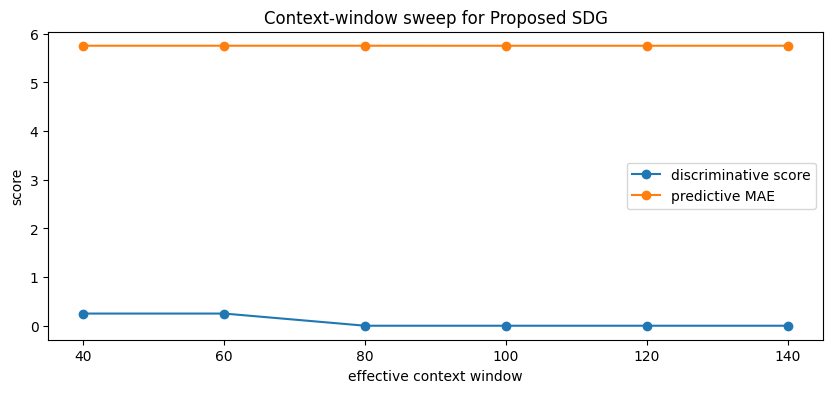

In [40]:
if RUN_BENCHMARK_COMPARISON and benchmark_results:
    real_reference = get_real_reference(benchmark_results)

    utility_rows = []
    for name, payload in benchmark_results.items():
        pred_score = posthoc_rnn_predictive_score(real_reference, payload["syn_arr"], epochs=12, hidden_dim=32, batch_size=32, seed=BENCHMARK_SEED)
        forecast_score = xgboost_forecasting_score(real_reference, payload["syn_arr"], seed=BENCHMARK_SEED)
        utility_rows.append({
            "model": display_name(name),
            "predictive_mae_rnn": pred_score.get("mae", np.nan),
            "predictive_rmse_rnn": pred_score.get("rmse", np.nan),
            "forecast_mae_xgb": forecast_score.get("mae", np.nan),
            "forecast_rmse_xgb": forecast_score.get("rmse", np.nan),
            "forecast_model_family": forecast_score.get("model_family", "xgboost"),
        })

    utility_df = pd.DataFrame(utility_rows).sort_values("predictive_mae_rnn")
    display(utility_df)
    utility_df.to_csv(OUT_DIR / "paper_utility_scores.csv", index=False)

    # Context-window sweep for proposed SDG
    CONTEXT_SWEEP_VALUES = [40, 60, 80, 100, 120, CONTEXT_LENGTH]
    CONTEXT_SWEEP_MAX_SKUS = 8

    if MODEL_READY:
        sweep_skus = list(TEST_SKUs)[:CONTEXT_SWEEP_MAX_SKUS]
        context_sweep_rows = []
        for ctx_len in CONTEXT_SWEEP_VALUES:
            real_list = []
            syn_list = []
            for sku in sweep_skus:
                sku_df = make_daily_series(panel, sku)
                decision_date = sku_df[TIME_COL].max() - pd.Timedelta(days=HORIZON)
                sku_train = sku_df[sku_df[TIME_COL] <= decision_date].copy()
                sku_test = sku_df[sku_df[TIME_COL] > decision_date].copy()
                if len(sku_train) < max(10, ctx_len) or len(sku_test) < PREDICTION_LENGTH:
                    continue

                short_context = sku_train[DEMAND_COL].astype(float).values[-ctx_len:]
                if len(short_context) < CONTEXT_LENGTH:
                    pad_val = float(short_context[0]) if len(short_context) else 0.0
                    short_context = np.concatenate([np.repeat(pad_val, CONTEXT_LENGTH - len(short_context)), short_context])

                context_dates = sku_train[TIME_COL].iloc[-min(len(sku_train), CONTEXT_LENGTH):].tolist()
                if len(context_dates) < CONTEXT_LENGTH:
                    last_dt = pd.to_datetime(sku_train[TIME_COL].iloc[-1])
                    context_dates = pd.date_range(end=last_dt, periods=CONTEXT_LENGTH, freq="D").tolist()

                future_dates = sku_test[TIME_COL].iloc[:PREDICTION_LENGTH].tolist()
                real_future = sku_test[DEMAND_COL].astype(float).values[:PREDICTION_LENGTH]

                try:
                    out = sdg.generate(
                        context_values=short_context,
                        horizon=PREDICTION_LENGTH,
                        metadata=None,
                        num_return_sequences=NUM_RETURN_SEQUENCES,
                        do_sample=True,
                        temperature=0.9,
                        top_p=0.95,
                        context_dates=context_dates,
                        future_dates=future_dates,
                        apply_seasonal_calibration=True,
                    )
                    syn_future = np.asarray(out["best_future"], dtype=float)
                    real_list.append(real_future)
                    syn_list.append(syn_future)
                except Exception as exc:
                    warnings.warn(f"Context sweep failed for SKU {sku} at context={ctx_len}: {exc}")

            if len(real_list):
                real_arr_ctx = np.asarray(real_list, dtype=float)
                syn_arr_ctx = np.asarray(syn_list, dtype=float)
                disc = posthoc_rnn_discriminative_score(real_arr_ctx, syn_arr_ctx, epochs=10, hidden_dim=24, batch_size=16, seed=BENCHMARK_SEED)
                pred = posthoc_rnn_predictive_score(real_arr_ctx, syn_arr_ctx, epochs=10, hidden_dim=24, batch_size=16, seed=BENCHMARK_SEED)
                context_sweep_rows.append({
                    "context_window": int(ctx_len),
                    "n_eval_skus": int(len(real_arr_ctx)),
                    "discriminative_score_rnn": disc.get("score", np.nan),
                    "predictive_mae_rnn": pred.get("mae", np.nan),
                })

        context_sweep_df = pd.DataFrame(context_sweep_rows).sort_values("context_window")
        display(context_sweep_df)
        if len(context_sweep_df):
            plt.figure(figsize=(10, 4))
            plt.plot(context_sweep_df["context_window"], context_sweep_df["discriminative_score_rnn"], marker="o", label="discriminative score")
            plt.plot(context_sweep_df["context_window"], context_sweep_df["predictive_mae_rnn"], marker="o", label="predictive MAE")
            plt.xlabel("effective context window")
            plt.ylabel("score")
            plt.title("Context-window sweep for Proposed SDG")
            plt.legend()
            plt.show()
        context_sweep_df.to_csv(OUT_DIR / "paper_context_window_sweep.csv", index=False)
    else:
        print("Context-window sweep skipped because the proposed SDG model is not ready.")
else:
    print("Paper-aligned utility block skipped because benchmark results are not available.")

### 15.3 Privacy

This block adds a **privacy against inference** benchmark with four attack models:
- NumericalMLP,
- NumericalLR,
- NumericalSVR,
- NumericalRadNN.

Lower attack performance indicates that the generated data is less useful for reconstructing held-out target values from observed prefixes.


/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/sklearn/neighbors/_regression.py:508: UserWarning: One or more samples have no neighbors within specified radius; predicting NaN.
  warnings.warn(empty_warning_msg)
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/anaconda3/envs/scenario-generation-env/lib/python3.10/site-packages/sklearn/neighbors/_regression.py:508: UserWarning: One or more samples have no neighbors within specified radius; predicting NaN.

,train_source,attack_model,mae,rmse,error
0,real_train_baseline,NumericalMLP,833.104454,2180.509591,NaN
1,real_train_baseline,NumericalLR,4470.954054,12698.467737,NaN
2,real_train_baseline,NumericalSVR,469.017161,2342.656700,NaN
3,real_train_baseline,NumericalRadNN,NaN,NaN,Input contains NaN.
4,Proposed SDG,NumericalMLP,528.007926,3246.787504,NaN
5,Proposed SDG,NumericalLR,1646.103448,7175.767198,NaN
6,Proposed SDG,NumericalSVR,166.221929,1337.609758,NaN
7,Proposed SDG,NumericalRadNN,NaN,NaN,Input contains NaN.
8,GAN,NumericalMLP,1019.142649,2314.308453,NaN
9,GAN,NumericalLR,1403.704063,3102.583850,NaN


Privacy-against-inference MAE table


train_source,DGAN,GAN,LSTM,Proposed SDG,TimeGAN,real_train_baseline
attack_model,,,,,,
NumericalLR,802.442993,1403.704063,1900.039924,1646.103448,220.867463,4470.954054
NumericalMLP,303.411686,1019.142649,346.942555,528.007926,239.572130,833.104454
NumericalRadNN,NaN,NaN,NaN,NaN,NaN,NaN
NumericalSVR,227.179171,764.541225,202.870518,166.221929,168.261805,469.017161


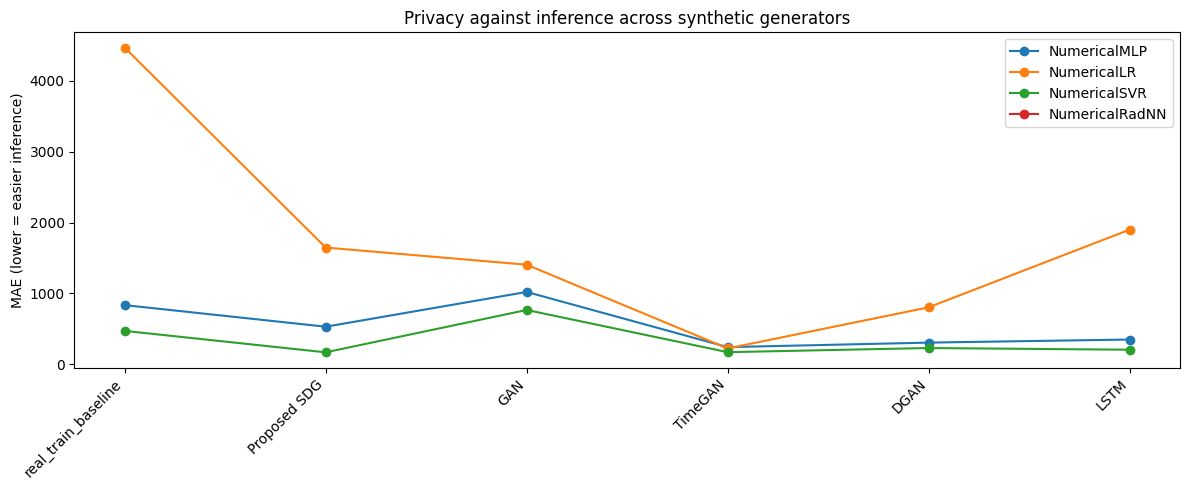

In [41]:
if RUN_BENCHMARK_COMPARISON and benchmark_results:
    privacy_df = privacy_inference_block(benchmark_results, seed=BENCHMARK_SEED)
    if len(privacy_df):
        display(privacy_df)
        privacy_df.to_csv(OUT_DIR / "paper_privacy_inference.csv", index=False)

        pivot_mae = privacy_df.pivot(index="attack_model", columns="train_source", values="mae")
        print("Privacy-against-inference MAE table")
        display(pivot_mae)

        plt.figure(figsize=(12, 5))
        for attack_name in privacy_df["attack_model"].dropna().unique():
            sub = privacy_df[privacy_df["attack_model"] == attack_name]
            plt.plot(sub["train_source"], sub["mae"], marker="o", label=attack_name)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("MAE (lower = easier inference)")
        plt.title("Privacy against inference across synthetic generators")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Privacy-against-inference block produced no rows.")
else:
    print("Paper-aligned privacy block skipped because benchmark results are not available.")

## 16) Final dimension scores and overall benchmark ranking

This section aggregates the metrics into three dimension scores:
- **Fidelity**: how closely the synthetic series preserves the real distribution and temporal structure;
- **Utility**: how useful the synthetic data is for downstream prediction and forecasting;
- **Privacy**: how hard it is for post hoc attack models to infer held-out targets from synthetic data.

Each dimension score is computed on a **0–100** scale using normalized rank-based scoring across the compared models. A higher score is better. The **overall score** is the unweighted mean of the three dimensions.


,model,fidelity_score,utility_score,privacy_score,overall_score
0,Proposed SDG,85.0,55.0,50.0,63.333333
1,LSTM,55.0,60.0,75.0,63.333333
2,GAN,35.0,20.0,100.0,51.666667
3,DGAN,40.0,60.0,25.0,41.666667
4,TimeGAN,35.0,55.0,0.0,30.000000


<Figure size 1000x500 with 0 Axes>

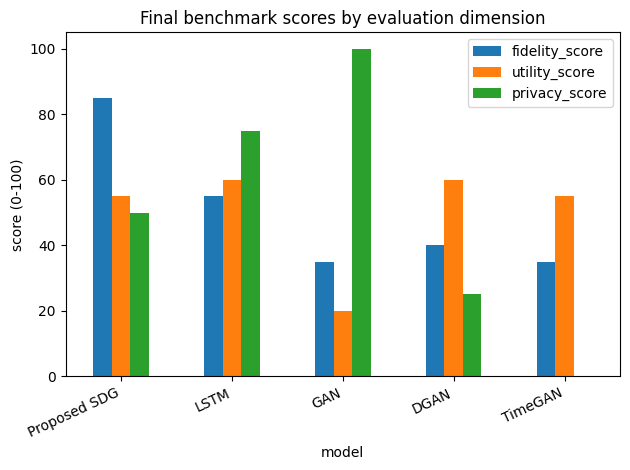

Best fidelity model: Proposed SDG
Best utility model: LSTM
Best privacy model: GAN


In [42]:
def _rank_score(values, higher_is_better=True, ideal=None):
    s = pd.to_numeric(pd.Series(values), errors="coerce")
    valid = s.notna()
    out = pd.Series(np.nan, index=s.index, dtype=float)
    if valid.sum() == 0:
        return out
    work = s[valid].astype(float)
    if ideal is not None:
        work = (work - float(ideal)).abs()
        higher_is_better = False
    if valid.sum() == 1:
        out.loc[valid] = 1.0
        return out
    ranks = work.rank(method="average", ascending=not higher_is_better)
    out.loc[valid] = 1.0 - (ranks - 1.0) / (len(work) - 1.0)
    return out


def _safe_merge(base_df, other_df, columns, on="model"):
    keep = [c for c in columns if c in other_df.columns]
    if not keep:
        return base_df
    merge_cols = [on] + keep
    return base_df.merge(other_df[merge_cols], on=on, how="left")


if RUN_BENCHMARK_COMPARISON and benchmark_results and 'fidelity_summary_df' in globals() and 'discriminative_df' in globals() and 'utility_df' in globals() and 'privacy_df' in globals():
    fidelity_df = fidelity_summary_df.copy()
    fidelity_df['model'] = fidelity_df['model'].replace(MODEL_DISPLAY_NAMES)

    discriminative_df_sc = discriminative_df.copy()
    if 'model' in discriminative_df_sc.columns:
        discriminative_df_sc['model'] = discriminative_df_sc['model'].replace(MODEL_DISPLAY_NAMES)

    utility_df_sc = utility_df.copy()
    if 'model' in utility_df_sc.columns:
        utility_df_sc['model'] = utility_df_sc['model'].replace(MODEL_DISPLAY_NAMES)

    privacy_df_sc = privacy_df.copy()
    if 'train_source' in privacy_df_sc.columns:
        privacy_df_sc['train_source'] = privacy_df_sc['train_source'].replace(MODEL_DISPLAY_NAMES)
    if 'model' in privacy_df_sc.columns:
        privacy_df_sc['model'] = privacy_df_sc['model'].replace(MODEL_DISPLAY_NAMES)

    if 'similarity_df' in globals():
        similarity_df_sc = similarity_df.copy()
        if 'model' in similarity_df_sc.columns:
            similarity_df_sc['model'] = similarity_df_sc['model'].replace(MODEL_DISPLAY_NAMES)
    else:
        similarity_df_sc = pd.DataFrame(columns=['model'])

    privacy_agg = (privacy_df_sc.groupby('train_source', as_index=False)
                   .agg(avg_privacy_attack_mae=('mae', 'mean'),
                        avg_privacy_attack_rmse=('rmse', 'mean'))
                   .rename(columns={'train_source': 'model'}))

    # Start from fidelity summary and then enrich with metrics pulled from benchmark_results / per-SKU tables
    score_df = fidelity_df.copy()

    extra_rows = []
    for raw_name, payload in benchmark_results.items():
        model_name = display_name(raw_name)
        metrics_local = dict(payload.get("metrics", {}))
        per_sku_df = payload.get("per_sku", pd.DataFrame())
        extra_rows.append({
            "model": model_name,
            "tstr_mae": metrics_local.get("tstr_mae", metrics_local.get("tstr", {}).get("mae", np.nan) if isinstance(metrics_local.get("tstr", {}), dict) else np.nan),
            "trts_mae": metrics_local.get("trts_mae", metrics_local.get("trts", {}).get("mae", np.nan) if isinstance(metrics_local.get("trts", {}), dict) else np.nan),
            "avg_rmse": float(per_sku_df["rmse"].mean()) if isinstance(per_sku_df, pd.DataFrame) and "rmse" in per_sku_df.columns and len(per_sku_df) else np.nan,
            "avg_mae": float(per_sku_df["mae"].mean()) if isinstance(per_sku_df, pd.DataFrame) and "mae" in per_sku_df.columns and len(per_sku_df) else np.nan,
        })
    extra_metrics_df = pd.DataFrame(extra_rows)

    score_df = _safe_merge(score_df, extra_metrics_df, ['tstr_mae', 'trts_mae', 'avg_rmse', 'avg_mae'])
    score_df = _safe_merge(score_df, discriminative_df_sc, ['discriminative_score_rnn'])
    score_df = _safe_merge(score_df, utility_df_sc, ['predictive_mae_rnn', 'forecast_mae_xgb'])
    score_df = _safe_merge(score_df, privacy_agg, ['avg_privacy_attack_mae'])
    score_df = _safe_merge(score_df, similarity_df_sc, ['avg_cosine_similarity_windowed', 'avg_jensen_shannon_distance_windowed'])

    # Fidelity: higher cosine, lower Wasserstein/JS/discriminative score, detection closer to 0.5
    fidelity_components = pd.DataFrame({'model': score_df['model']})
    if 'wasserstein_distance' in score_df.columns:
        fidelity_components['wasserstein'] = _rank_score(score_df['wasserstein_distance'], higher_is_better=False)
    if 'avg_cosine_similarity' in score_df.columns:
        fidelity_components['cosine'] = _rank_score(score_df['avg_cosine_similarity'], higher_is_better=True)
    if 'avg_jensen_shannon_distance' in score_df.columns:
        fidelity_components['js'] = _rank_score(score_df['avg_jensen_shannon_distance'], higher_is_better=False)
    if 'discriminative_score_rnn' in score_df.columns:
        fidelity_components['disc'] = _rank_score(score_df['discriminative_score_rnn'], higher_is_better=False)
    if 'detection_auc' in score_df.columns:
        fidelity_components['auc_ideal'] = _rank_score(score_df['detection_auc'], ideal=0.5)
    fidelity_cols = [c for c in fidelity_components.columns if c != 'model']
    fidelity_components['fidelity_score'] = 100.0 * fidelity_components[fidelity_cols].mean(axis=1, skipna=True)

    # Utility: lower downstream predictive and forecasting errors, plus lower transfer / held-out RMSE errors
    utility_components = pd.DataFrame({'model': score_df['model']})
    if 'predictive_mae_rnn' in score_df.columns:
        utility_components['predictive_mae_rnn'] = _rank_score(score_df['predictive_mae_rnn'], higher_is_better=False)
    if 'forecast_mae_xgb' in score_df.columns:
        utility_components['forecast_mae_xgb'] = _rank_score(score_df['forecast_mae_xgb'], higher_is_better=False)
    if 'tstr_mae' in score_df.columns:
        utility_components['tstr_mae'] = _rank_score(score_df['tstr_mae'], higher_is_better=False)
    if 'trts_mae' in score_df.columns:
        utility_components['trts_mae'] = _rank_score(score_df['trts_mae'], higher_is_better=False)
    if 'avg_rmse' in score_df.columns:
        utility_components['avg_rmse'] = _rank_score(score_df['avg_rmse'], higher_is_better=False)
    utility_cols = [c for c in utility_components.columns if c != 'model']
    utility_components['utility_score'] = 100.0 * utility_components[utility_cols].mean(axis=1, skipna=True)

    # Privacy: higher attack error means the synthetic data leaks less target information
    privacy_components = pd.DataFrame({'model': score_df['model']})
    if 'avg_privacy_attack_mae' in score_df.columns:
        privacy_components['attack_mae'] = _rank_score(score_df['avg_privacy_attack_mae'], higher_is_better=True)
    privacy_cols = [c for c in privacy_components.columns if c != 'model']
    privacy_components['privacy_score'] = 100.0 * privacy_components[privacy_cols].mean(axis=1, skipna=True)

    final_score_df = score_df[['model']].copy()
    final_score_df = final_score_df.merge(fidelity_components[['model', 'fidelity_score']], on='model', how='left')
    final_score_df = final_score_df.merge(utility_components[['model', 'utility_score']], on='model', how='left')
    final_score_df = final_score_df.merge(privacy_components[['model', 'privacy_score']], on='model', how='left')
    final_score_df['overall_score'] = final_score_df[['fidelity_score', 'utility_score', 'privacy_score']].mean(axis=1, skipna=True)
    final_score_df = final_score_df.sort_values(['overall_score', 'fidelity_score'], ascending=False).reset_index(drop=True)

    display(final_score_df)
    final_score_df.to_csv(OUT_DIR / 'paper_final_dimension_scores.csv', index=False)

    plt.figure(figsize=(10, 5))
    score_plot = final_score_df.set_index('model')[['fidelity_score', 'utility_score', 'privacy_score']]
    score_plot.plot(kind='bar')
    plt.ylabel('score (0-100)')
    plt.title('Final benchmark scores by evaluation dimension')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

    if len(final_score_df):
        best_fidelity = final_score_df.sort_values('fidelity_score', ascending=False).iloc[0]['model']
        best_utility = final_score_df.sort_values('utility_score', ascending=False).iloc[0]['model']
        best_privacy = final_score_df.sort_values('privacy_score', ascending=False).iloc[0]['model']
        print('Best fidelity model:', best_fidelity)
        print('Best utility model:', best_utility)
        print('Best privacy model:', best_privacy)
else:
    print('Final dimension scoring skipped because one or more paper-aligned result tables are unavailable.')

In [43]:
if 'final_score_df' in globals() and isinstance(final_score_df, pd.DataFrame) and len(final_score_df):
    _fs = final_score_df.copy()
    top_overall = _fs.sort_values('overall_score', ascending=False).iloc[0]
    top_fidelity = _fs.sort_values('fidelity_score', ascending=False).iloc[0]
    top_utility = _fs.sort_values('utility_score', ascending=False).iloc[0]
    top_privacy = _fs.sort_values('privacy_score', ascending=False).iloc[0]

    proposed_row = _fs[_fs['model'] == 'Proposed SDG']
    if len(proposed_row):
        proposed_row = proposed_row.iloc[0]
        proposed_sentence = (
            f"The proposed model obtained a fidelity score of {proposed_row['fidelity_score']:.1f}, "
            f"a utility score of {proposed_row['utility_score']:.1f}, a privacy score of {proposed_row['privacy_score']:.1f}, "
            f"and an overall score of {proposed_row['overall_score']:.1f}. "
        )
    else:
        proposed_sentence = ""

    conclusion = (
        f"Table-based aggregation of the benchmark results shows that {top_overall['model']} achieved the best overall performance "
        f"with an overall score of {top_overall['overall_score']:.1f}. "
        f"In the fidelity dimension, the strongest model was {top_fidelity['model']} with a score of {top_fidelity['fidelity_score']:.1f}, "
        f"indicating the closest match to the real data distribution and temporal structure. "
        f"In the utility dimension, {top_utility['model']} obtained the best score of {top_utility['utility_score']:.1f}, "
        f"which reflects stronger downstream predictive usefulness. "
        f"In the privacy dimension, {top_privacy['model']} reached the highest score of {top_privacy['privacy_score']:.1f}, "
        f"suggesting stronger resistance to inference-based attacks. "
        f"{proposed_sentence}"
        "Overall, these results show that the compared methods show a trade-off between realism, downstream usefulness, and privacy preservation, "
        "while the proposed model can be positioned clearly within this three-dimensional evaluation framework."
    )

    print(conclusion)
else:
    print('Conclusion skipped because final_score_df is not available.')

Table-based aggregation of the benchmark results shows that Proposed SDG achieved the best overall performance with an overall score of 63.3. In the fidelity dimension, the strongest model was Proposed SDG with a score of 85.0, indicating the closest match to the real data distribution and temporal structure. In the utility dimension, LSTM obtained the best score of 60.0, which reflects stronger downstream predictive usefulness. In the privacy dimension, GAN reached the highest score of 100.0, suggesting stronger resistance to inference-based attacks. The proposed model obtained a fidelity score of 85.0, a utility score of 55.0, a privacy score of 50.0, and an overall score of 63.3. Overall, these results show that the compared methods show a trade-off between realism, downstream usefulness, and privacy preservation, while the proposed model can be positioned clearly within this three-dimensional evaluation framework.
